# **Contents** ✨📊: graphs, correlations, chi-square tests and more functions for data cleaning.

### This notebook is a comprehensible guide to data extraction, interpretation and visualisation. Just go through each code cell and run each of them to see the results! You are encouraged to use these visualisations in your mini project. 🎯📈💡

## Contents: Plot Types 📌

- [Histogram](#histogram---visualizing-distributions-of-continuous-data)
- [Bar Graph](#bar-graph---comparing-categories)
- [Stacked Bar Graph](#stacked-bar-graph---comparing-parts-of-a-whole-across-categories)
- [Scatter Plot](#scatter-plot---visualizing-relationships-between-variables)
- [Correlation Heatmap](#correlation-heatmap---visualizing-relationships-between-multiple-variables)
- [Time Series Heatmap](#time-series-heatmap---visualizing-patterns-over-time-and-categories)
- [Bubble Chart](#bubble-chart---scatter-plot-with-size-and-color-dimensions)
- [Joint Plot](#joint-plot-bivariate-analysis-with-marginal-distributions)
- [Ridge Plot](#ridge-plot-joy-plot---visualizing-distributions-across-categories)

Tip: If a link does not jump correctly in your Jupyter setup, run the notebook once and try again.

## Necessary Imports

This notebook requires several Python libraries for data analysis and visualization. Below is a detailed explanation of each import and its purpose:

### Core Data Science Libraries

- **[pandas](https://pandas.pydata.org/docs/)** - Essential library for data manipulation and analysis. Provides DataFrame objects for handling structured data, reading/writing various file formats, and performing data cleaning operations.

- **[NumPy](https://numpy.org/doc/stable/)** - Fundamental package for scientific computing. Provides support for large multi-dimensional arrays, mathematical functions, and linear algebra operations.

- **[Matplotlib](https://matplotlib.org/stable/contents.html)** - Comprehensive library for creating static, animated, and interactive visualizations. We use `matplotlib.pyplot` for creating plots like histograms, bar charts, and line graphs.

- **[Seaborn](https://seaborn.pydata.org/)** - Statistical data visualization library built on top of Matplotlib. Provides a high-level interface for creating attractive and informative statistical graphics like heatmaps, box plots, and violin plots.

### Specialized Visualization Tools

- **[waterfall-chart](https://pypi.org/project/waterfall-chart/)** - Creates waterfall charts for visualizing cumulative effects of sequential positive and negative values. Install with: `pip install waterfall-chart` (note: imported as `waterfall_chart`)

- **[pandas.plotting.parallel_coordinates](https://pandas.pydata.org/docs/reference/api/pandas.plotting.parallel_coordinates.html)** - Specialized plotting function for creating parallel coordinates plots to visualize multivariate data.

### Statistical Analysis

- **[SciPy Stats](https://docs.scipy.org/doc/scipy/reference/stats.html)** - Statistical functions from SciPy library. We use:
  - `chi2_contingency` - Performs chi-square test of independence for contingency tables
  - `chi2` - Chi-square distribution functions for statistical testing

### Machine Learning Datasets

- **[sklearn.datasets](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.datasets)** - Provides access to toy datasets and sample generators. We use `load_iris` to load the famous Iris dataset for demonstration purposes.

---

**Note**: Most of these libraries come pre-installed with Anaconda or can be installed using pip. The waterfall-chart package may need to be installed separately.

In [ ]:
# Install waterfall-chart and sklearn packages (run this cell if you get ImportError for waterfall_chart or sklearn)

# Uncomment the line below and run if needed:
!pip install -q waterfallcharts scikit-learn


# Core data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Specialized visualization
import waterfall_chart
from pandas.plotting import parallel_coordinates

# Statistical analysis
from scipy.stats import chi2_contingency, chi2

# Machine learning datasets
from sklearn.datasets import load_iris

# To remove warnings
import warnings
warnings.filterwarnings('ignore')


  Preparing metadata (setup.py) ... done


## **Box Plot (Box-and-Whisker Plot) - Visualizing Distribution and Identifying Outliers**

A **box plot** is a standardized way of displaying the distribution of data based on a five-number summary: minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum. It's excellent for comparing distributions and identifying outliers.

### What Does a Box Plot Show?

- **Central Tendency**: The median (middle line in box) shows the center of your data
- **Spread**: The box height (IQR) shows where the middle 50% of data falls
- **Skewness**: Asymmetric box or whiskers indicate skewed distributions
- **Outliers**: Individual points beyond whiskers are potential outliers
- **Comparison**: Easy to compare multiple groups side-by-side

### The Five-Number Summary:

1. **Minimum**: The smallest value (excluding outliers)
2. **Q1 (First Quartile/25th percentile)**: 25% of data falls below this value
3. **Median (Q2/50th percentile)**: The middle value - 50% below, 50% above
4. **Q3 (Third Quartile/75th percentile)**: 75% of data falls below this value
5. **Maximum**: The largest value (excluding outliers)

### Understanding Box Plot Components:

- **Box**: Contains the middle 50% of data (from Q1 to Q3)
- **Line inside box**: The median (Q2)
- **IQR (Interquartile Range)**: Q3 - Q1 (height of the box)
- **Whiskers**: Extend to the most extreme non-outlier data points
  - Upper whisker: Up to Q3 + 1.5×IQR
  - Lower whisker: Down to Q1 - 1.5×IQR
- **Outliers**: Points beyond the whiskers (shown as individual dots)
  - Values > Q3 + 1.5×IQR or < Q1 - 1.5×IQR

### Why Use Box Plots?

- **Outlier Detection**: Automatically identifies unusual values that need investigation
- **Distribution Comparison**: Compare multiple groups efficiently in one plot
- **Robust**: Not affected by extreme outliers like mean-based measures
- **Compact**: Shows key statistics without overwhelming detail
- **Standard**: Universally recognized format for statistical reporting

### When to Use:

- Comparing distributions across multiple groups or categories
- Identifying outliers in your data
- Checking for data quality issues (unexpected extreme values)
- Exploring before/after treatment effects
- Presenting statistical summaries in reports
- When you have multiple groups to compare (2-20 groups work well)

### Key Parameters:

- `column`: Specific column(s) to plot
- `by`: Group data by a categorical variable for comparison
- `vert`: Vertical (True, default) or horizontal (False) orientation
- `showmeans`: Display mean as a separate marker
- `showfliers`: Whether to show outliers (default True)
- `patch_artist`: Allows filling boxes with color

### Best Practices:

1. **Use for multiple groups**: Box plots shine when comparing 2+ distributions
2. **Check for outliers**: Investigate points beyond whiskers - they might be errors or interesting cases
3. **Consider sample size**: Box plots work best with at least 20-30 observations per group
4. **Add data points**: For small samples, overlay individual points (strip plot or swarm plot)
5. **Combine with violin plots**: For larger datasets, violin plots show more distributional detail

### When NOT to Use:

- Very small samples (<10 points) - better to show all points
- When you need to show full distribution shape - use histogram or violin plot instead
- Single variable with no comparisons - histogram might be more informative

In [25]:
box_df = pd.DataFrame({'score_a': [1,2,3,4,5,6,7,8,9]})
box_df

,score_a
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9


### Quick Reference: Box Plot Statistics

**Key Terms:**
- **Median (Q2 / 50th Percentile)**: The middle value when data is ordered. Half the data is below, half is above.
- **First Quartile (Q1 / 25th Percentile)**: The value below which 25% of the data falls.
- **Third Quartile (Q3 / 75th Percentile)**: The value below which 75% of the data falls.
- **Interquartile Range (IQR)**: Q3 - Q1. Represents the range containing the middle 50% of data.
- **Whiskers**: Extend to the most extreme values within 1.5×IQR from the quartiles.
- **Outliers**: Data points that fall outside the whiskers:
  - Upper outliers: Values > Q3 + 1.5×IQR
  - Lower outliers: Values < Q1 - 1.5×IQR

**Important**: Box plots are excellent for identifying outliers automatically. Any point shown as a dot beyond the whiskers deserves investigation - it could be a data entry error, measurement problem, or genuinely unusual case!

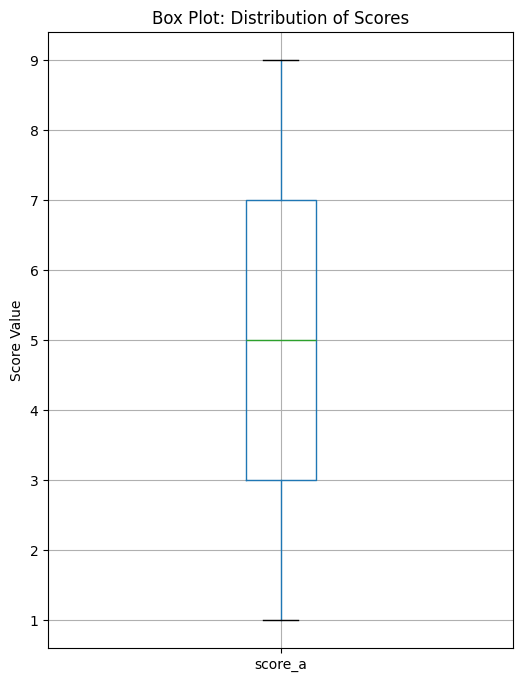

In [26]:
# Create a box plot for a single variable
# This visualizes the distribution using the five-number summary

box_df.boxplot(column=['score_a'], figsize=(6, 8))

# Add labels
plt.ylabel('Score Value')
plt.title('Box Plot: Distribution of Scores')

# Display the plot
plt.show()

# In this example:
# - The box shows Q1 (bottom), median (middle line), and Q3 (top)
# - Whiskers extend to the minimum and maximum values
# - Any points beyond whiskers would be outliers (none in this simple dataset)

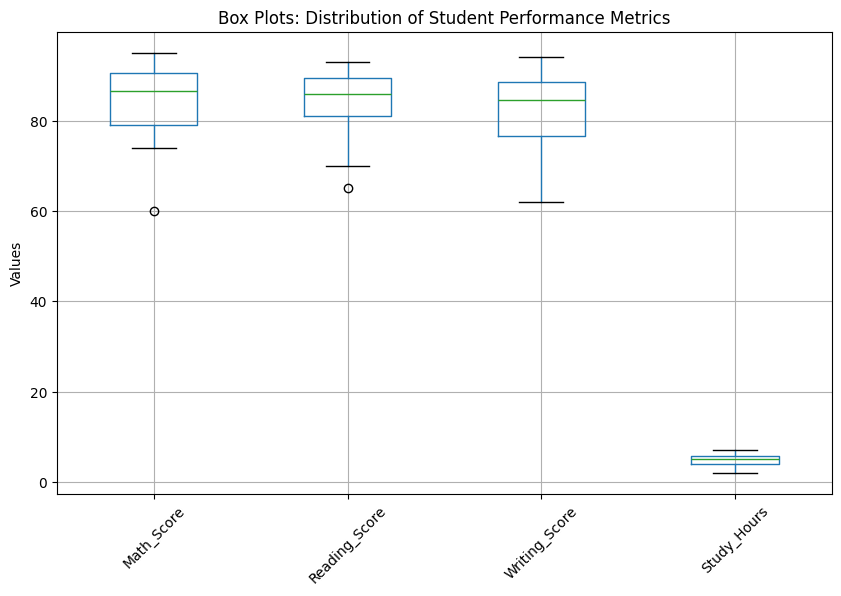

In [27]:
# Create box plots for all numeric columns in the DataFrame
# This allows comparison of distributions across multiple variables

# -----------------------------
df = pd.DataFrame({
    "Math_Score": [78, 85, 92, 88, 74, 95, 60, 82, 89, 91],
    "Reading_Score": [80, 87, 90, 85, 70, 93, 65, 84, 88, 90],
    "Writing_Score": [75, 83, 89, 86, 72, 94, 62, 81, 87, 92],
    "Study_Hours": [4, 5, 6, 5, 3, 7, 2, 4, 6, 5]
})

# -----------------------------
# Box plot for all numeric columns
# -----------------------------
df.boxplot(figsize=(10, 6))

plt.ylabel("Values")
plt.title("Box Plots: Distribution of Student Performance Metrics")
plt.xticks(rotation=45)

plt.show()

# Interpretation tips:
# - Compare median positions (middle lines) to see which variables have higher/lower centers
# - Compare box heights (IQR) to see which variables have more/less variability
# - Look for outliers (dots beyond whiskers) in each variable
# - Check for skewness: is the median closer to Q1 or Q3?

## **Violin Plot - Box Plot Enhanced with Distribution Shape**

A **violin plot** combines the benefits of a box plot with a kernel density plot (KDE). It shows the full distribution shape of the data along with key summary statistics, making it more informative than box plots, especially for larger datasets.

### What Does a Violin Plot Show?

- **Distribution Shape**: The width at each point shows the density of data at that value
- **Summary Statistics**: Often includes a small box plot inside showing median and quartiles
- **Modality**: Reveals if data has one peak (unimodal), two peaks (bimodal), or multiple modes
- **Symmetry**: Shows if distribution is symmetric or skewed
- **Comparison**: Easy to compare distribution shapes across groups

### Why Use Violin Plots?

- **More Information**: Shows the complete probability distribution, not just summary statistics
- **Detailed Shape**: Reveals bumps, peaks, and gaps that box plots miss
- **Better for Large Datasets**: With many observations, the full distribution shape becomes meaningful
- **Bimodal Detection**: Can identify multiple peaks in the data (box plots cannot)
- **Aesthetic**: Visually appealing while being highly informative

### Violin Plot vs. Box Plot:

| Feature | Box Plot | Violin Plot |
|---------|----------|-------------|
| Shows median, quartiles | ✓ | ✓ |
| Identifies outliers | ✓ | Sometimes |
| Shows distribution shape | ✗ | ✓ |
| Shows multiple peaks | ✗ | ✓ |
| Works with small samples | ✓ | ✗ |
| Computation | Fast | Slower (KDE) |

### When to Use:

- You have a moderate to large dataset (50+ observations per group recommended)
- Distribution shape is important (checking for normality, multimodality)
- Comparing distributions across multiple categories
- When you want more detail than a box plot provides
- Presenting to audiences familiar with statistical visualizations

### Key Parameters:

- `x`: Variable for x-axis (often categorical for grouping)
- `y`: Variable for y-axis (continuous data to show distribution)
- `data`: DataFrame containing the data
- `inner`: What to show inside violin:
  - `'box'`: Small box plot (default in some libraries)
  - `'quartile'`: Lines at quartiles
  - `'point'` or `'stick'`: Individual observations
  - `None`: Just the distribution shape
- `scale`: How to scale violin width:
  - `'area'`: All violins have same area
  - `'count'`: Width scaled by sample size
  - `'width'`: All violins have same max width
- `bw`: Bandwidth for KDE (controls smoothness)

### Best Practices:

1. **Require adequate sample size**: Need 50+ observations per group for meaningful distribution shape
2. **Combine with box plot**: Include inner box plot to show quartiles and outliers
3. **Use for comparison**: Most effective when comparing 2-6 groups side-by-side
4. **Choose colors wisely**: Use distinct colors for different groups
5. **Check KDE bandwidth**: Adjust smoothness - too smooth hides detail, too rough shows noise

### When NOT to Use:

- Small samples (<30 points) - use box plots or strip plots instead
- Audience unfamiliar with KDE - box plots might be clearer
- When simple summary statistics suffice - box plots are simpler
- Too many groups (>10) - becomes cluttered

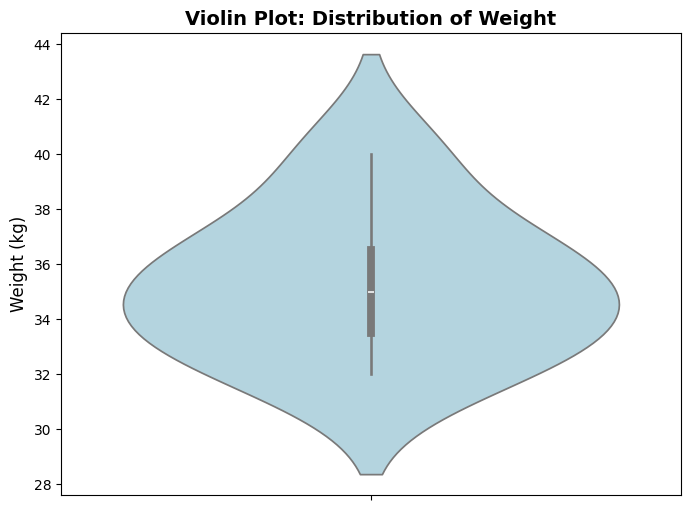

In [28]:
# Create a violin plot to show the distribution of Weight
# The violin shape shows the probability density at different values

# Dataframe of values
df_violin = pd.DataFrame({'Weight':[33,36,34,40,32,37,35], 'AgeM': [48,64,53,70,44,66,59], 'Baby Teeth':[19,12,18,5,20,10,15], "Eye Color":[1,3,2,2,3,1,2] })

# Create a more informative violin plot
plt.figure(figsize=(8, 6))

# Create violin plot with enhanced styling
# inner='box': Adds a mini box plot inside showing quartiles and median
# color: Sets the fill color
sns.violinplot(y=df_violin['Weight'], inner='box', color='lightblue')

# Add labels and title
plt.ylabel('Weight (kg)', fontsize=12)
plt.title('Violin Plot: Distribution of Weight', fontsize=14, fontweight='bold')

# Display the plot
plt.show()

# Interpretation:
# - The width of the violin at any height shows how many data points have that value
# - Wider sections = more data points at that value (higher density)
# - The mini box plot inside shows the median and quartiles
# - This is more informative than a box plot when you have enough data points

# Note: With only 7 data points in df, this is a simple example.
# Violin plots work best with 50+ observations!

## **Data Visualization: Histograms, Bar Graphs, and Scatter Plots**

In this section, we'll explore four fundamental visualization types using a comprehensive student performance dataset. Understanding these visualizations is crucial for data analysis and interpretation.

---

## **Histogram - Visualizing Distributions of Continuous Data**

A **histogram** is a fundamental statistical graph that displays the distribution of continuous numerical data by dividing it into intervals (called bins) and showing the frequency of observations in each interval.

### What Does a Histogram Show?

- **Distribution Shape**: Reveals whether data is normally distributed, skewed left/right, bimodal, or uniform
- **Central Tendency**: Shows where most data points cluster (mean, median regions)
- **Spread**: Displays the range and variability of your data
- **Outliers**: Helps identify unusual values that fall far from the main distribution

### Why Use Histograms?

- **Quick Overview**: Get an immediate visual sense of your data's distribution
- **Pattern Recognition**: Identify skewness, gaps, or multiple peaks in your data
- **Data Quality Check**: Spot data entry errors or unexpected patterns
- **Statistical Analysis**: Essential first step before applying statistical tests that assume normality

### When to Use:

- Exploring a single continuous variable (temperature, age, salary, test scores)
- Checking if data follows a normal distribution before hypothesis testing
- Identifying data quality issues or outliers
- Comparing distributions by creating multiple histograms side-by-side

### Key Parameters:

- `bins`: Number of intervals (default: 10). More bins = more detail, fewer bins = smoother pattern
  - Too few bins: May hide important patterns
  - Too many bins: May create noise and make patterns harder to see
  - Rule of thumb: Start with √n bins (where n = number of observations)
- `edgecolor`: Adds borders to bars for better visibility
- `alpha`: Transparency (0-1) - useful when overlaying multiple histograms
- `density`: If True, shows probability density instead of raw counts

### Best Practices:

1. **Choose bins wisely**: Experiment with different bin numbers to find the most informative view
2. **Label clearly**: Always include axis labels and units
3. **Consider your audience**: Use appropriate bin sizes for the precision needed
4. **Watch for artifacts**: Very small bin sizes can create misleading patterns from random noise

---

## **Bar Graph - Comparing Categories**

A **bar graph** (or bar chart) is one of the most widely used visualizations for comparing values across different categories. Each category is represented by a bar, and the length or height of the bar corresponds to its value.

### What Does a Bar Graph Show?

- **Category Comparison**: Directly compares quantities across different groups
- **Rankings**: Makes it easy to see which categories have the highest/lowest values
- **Differences**: Highlights magnitude of differences between categories
- **Proportions**: Shows how each category contributes to the overall picture

### Why Use Bar Graphs?

- **Intuitive**: Human eyes excel at comparing bar lengths
- **Versatile**: Works for any categorical data (products, regions, time periods, etc.)
- **Clear**: Simple and universally understood
- **Flexible**: Can be horizontal or vertical, grouped or stacked

### When to Use:

- Comparing quantities across discrete categories (sales by product, grades by student, etc.)
- Showing rankings or ordered data (top 10 cities, best performers, etc.)
- Displaying survey results or counts by category
- When you have 2-20 categories (too many makes it cluttered)

### Key Parameters:

- `kind='bar'`: Creates vertical bars (use `kind='barh'` for horizontal bars)
- `figsize=(width, height)`: Controls the size of the figure in inches
- `width`: Controls bar width (0-1, where 1 means bars touch each other)
- `color`: Single color or list of colors for each bar
- `rot`: Rotation angle for x-axis labels (useful for long category names)

### Best Practices:

1. **Start axis at zero**: Bars should always start at 0 to avoid misleading comparisons
2. **Sort meaningfully**: Arrange bars by value (descending/ascending) or logically (alphabetically, chronologically)
3. **Limit categories**: Too many bars (>15-20) become hard to read - consider grouping or using a different chart
4. **Use horizontal bars**: For long category names, horizontal bars prevent label overlap
5. **Add data labels**: Consider adding values on top of bars for precise reading

---

## **Stacked Bar Graph - Comparing Parts of a Whole Across Categories**

A **stacked bar graph** extends the basic bar chart by dividing each bar into segments, where each segment represents a subcategory. The segments are stacked on top of each other, and the total height shows the sum across all subcategories.

### What Does a Stacked Bar Graph Show?

- **Part-to-Whole Relationships**: Shows how each category breaks down into components
- **Total and Components**: Displays both the overall total AND the contribution of each part
- **Trends Across Categories**: Reveals how component proportions change across different groups
- **Composition Comparison**: Compares both totals and internal composition between categories

### Why Use Stacked Bar Graphs?

- **Multi-dimensional**: Shows two dimensions of data (categories and subcategories) in one chart
- **Space Efficient**: More compact than showing multiple separate bar charts
- **Total Values**: The top of each bar shows the total, making it easy to compare overall sizes
- **Component Visibility**: Each segment's size shows its contribution

### When to Use:

- Showing how totals break down into components (sales by product type across regions, revenue by source over time)
- Comparing both overall totals AND internal composition across categories
- Budget breakdowns across departments
- Survey responses showing multiple answer options per question
- When you have 2-5 subcategories (too many makes it hard to read)

### Key Parameters:

- `bottom`: Specifies the starting position of bars (used to stack bars on top of each other)
- `label`: Adds legend entries for each segment
- `color`: Different colors for each segment help distinguish them
- `width`: Bar width (default 0.8)
- `alpha`: Transparency for better visual appeal

### Best Practices:

1. **Limit subcategories**: Use 2-5 segments maximum - more becomes cluttered
2. **Use distinct colors**: Choose colors that are easily distinguishable
3. **Order matters**: Place most important category at the bottom (easiest to compare across bars)
4. **Include legend**: Always add a legend to identify what each color represents
5. **Consider 100% stacked**: For comparing proportions rather than absolute values, normalize to 100%

### When NOT to Use:

- Comparing values within a category (use grouped bar chart instead)
- When you have many subcategories (consider a different visualization like grouped bars)
- When precise comparison of middle segments is critical (hard to compare segments not starting at the same baseline)

---

## **Scatter Plot - Exploring Relationships Between Two Variables**

A **scatter plot** (or scatter diagram) displays individual data points on a two-dimensional plane, where each point represents the values of two variables. The position of each point is determined by its x-coordinate (one variable) and y-coordinate (another variable).

### What Does a Scatter Plot Show?

- **Relationships**: Reveals whether two variables are related (correlation)
- **Direction**: Shows if the relationship is positive (both increase together), negative (one increases as other decreases), or no relationship
- **Strength**: Indicates how closely the variables are related (tight clustering vs. wide spread)
- **Outliers**: Identifies unusual data points that don't fit the general pattern
- **Patterns**: Can reveal linear, curved, or clustered patterns in data

### Why Use Scatter Plots?

- **Correlation Detection**: First step in identifying if two variables are related
- **Trend Analysis**: Visualizes how one variable changes with another
- **Outlier Identification**: Spots unusual cases that need investigation
- **Hypothesis Testing**: Helps verify or reject assumptions about variable relationships
- **Predictive Insights**: Foundation for regression analysis and predictive modeling

### When to Use:

- Exploring relationships between two continuous variables (height vs. weight, age vs. income, temperature vs. sales)
- Checking for correlation before calculating correlation coefficients
- Identifying linear or non-linear patterns
- Comparing multiple groups using colors
- Finding outliers in bivariate data

### Types of Relationships You Can Identify:

1. **Positive Correlation**: Points trend upward from left to right (as X increases, Y increases)
2. **Negative Correlation**: Points trend downward (as X increases, Y decreases)
3. **No Correlation**: Points scattered randomly with no clear pattern
4. **Non-linear**: Points follow a curve rather than a straight line
5. **Clusters**: Distinct groups of points separate from others

### Key Parameters:

- `x`, `y`: The two variables to plot against each other
- `s`: Size of the markers (useful for adding a third dimension)
- `c`: Color of markers (can map to a third variable for color-coding)
- `alpha`: Transparency (0-1) - helpful when many points overlap
- `marker`: Shape of points ('o' for circle, 's' for square, '^' for triangle, etc.)

### Best Practices:

1. **Add trend lines**: Include a regression line to highlight the relationship
2. **Label axes clearly**: Always specify what each axis represents with units
3. **Use appropriate scale**: Both axes should cover the relevant data range
4. **Handle overplotting**: Use transparency (alpha) or jittering when many points overlap
5. **Calculate correlation**: Follow up with numerical correlation coefficient (Pearson's r)

---


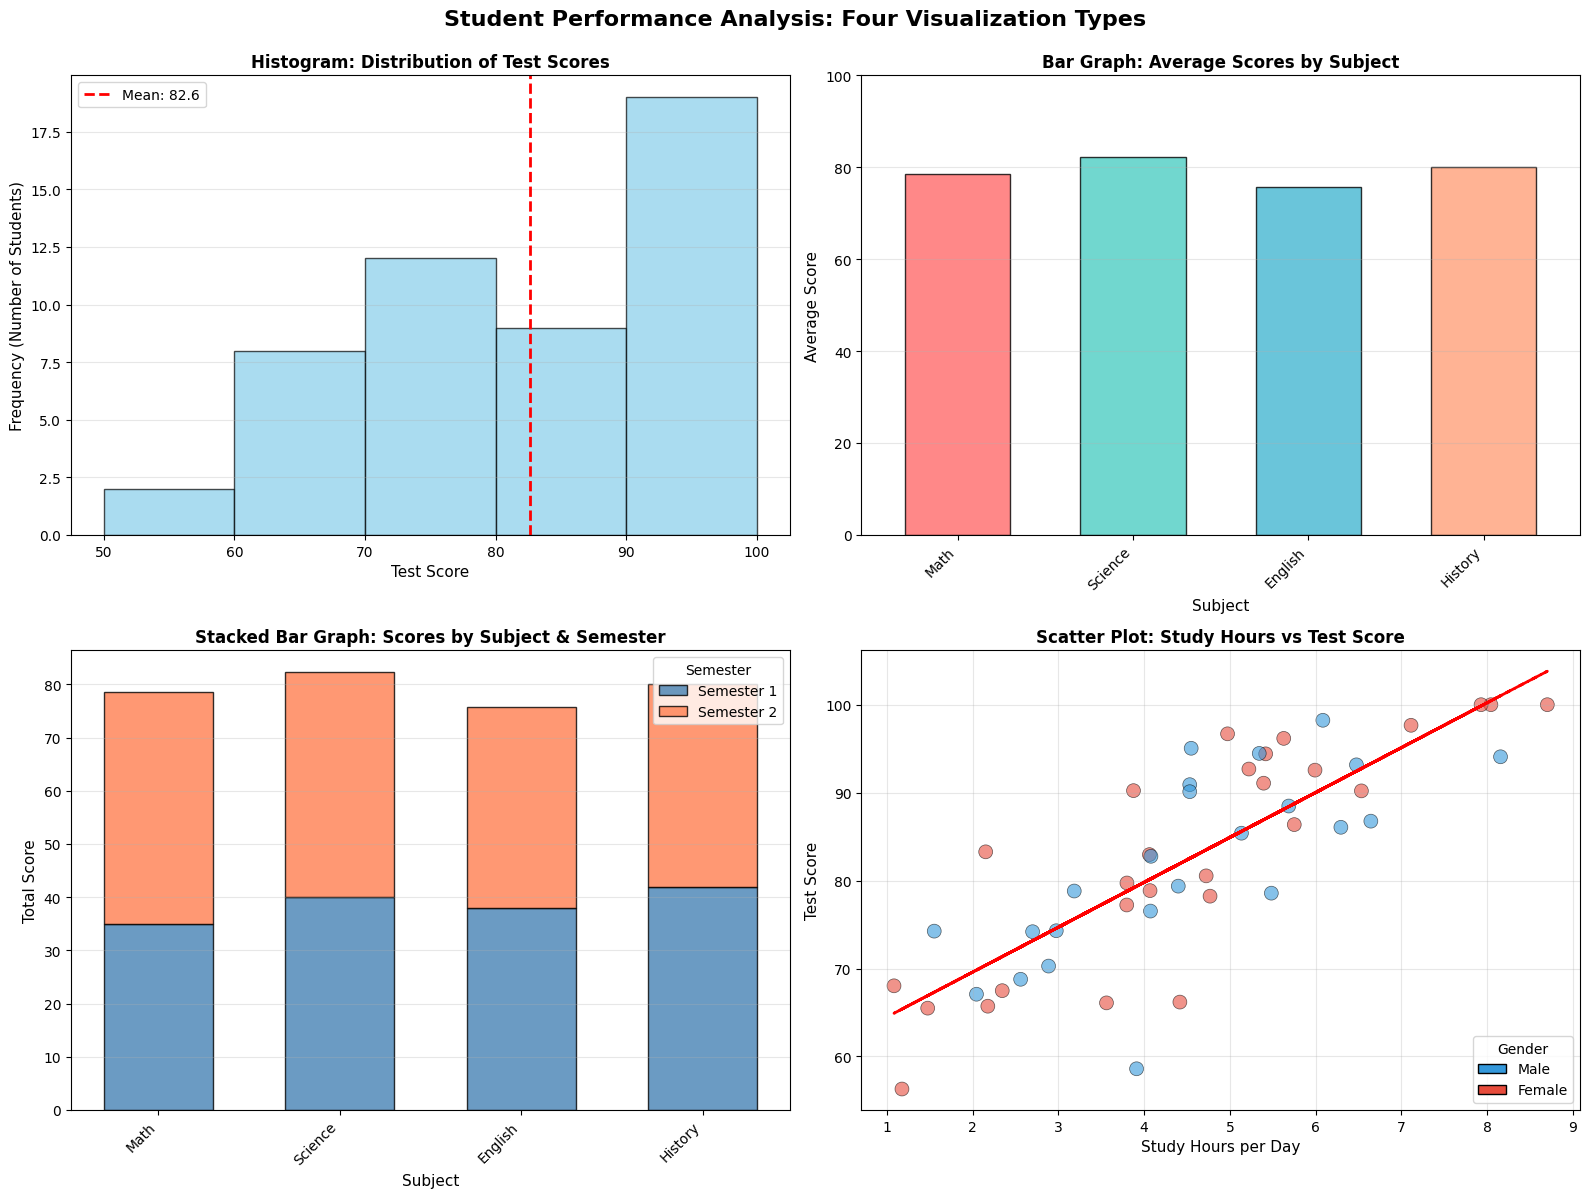


STUDENT PERFORMANCE DATASET (First 10 rows)
 Study_Hours  Test_Score  Attendance_Pct  Previous_GPA Gender
    5.993428   92.559813       86.063100      3.926344 Female
    4.723471   80.536699       88.030948      3.714668 Female
    6.295377   86.061509       89.801805      3.517223   Male
    8.046060  100.000000       90.988614      4.000000 Female
    4.531693   90.906462       91.920187      3.906051   Male
    4.531726   90.108871       94.547472      3.587872   Male
    8.158426   94.078388      100.000000      4.000000   Male
    6.534869   90.200648       93.423051      3.946163 Female
    4.061051   82.955364       92.026593      3.301716 Female
    6.085120   98.229961       94.185261      4.000000   Male

Dataset Summary: 50 students
Average Study Hours: 4.55 hours/day
Average Test Score: 82.61
Score Range: 56.3 - 100.0


In [35]:
## **Comprehensive Example: Student Performance Dataset**

# -----------------------------------------------------------------------------------------------------
# -------------------------------- Dataset Creation ---------------------------------------------------
# -----------------------------------------------------------------------------------------------------

# Create a comprehensive student performance dataset
# This dataset contains information about 50 students with multiple performance metrics
np.random.seed(42)  # For reproducibility

# Generate student data
n_students = 50

# Study hours (continuous variable) - normally distributed around 5 hours with some variation
study_hours = np.random.normal(5, 2, n_students)
study_hours = np.clip(study_hours, 1, 10)  # Clip to realistic range

# Test scores (continuous variable) - correlated with study hours plus some randomness
test_scores = 60 + study_hours * 5 + np.random.normal(0, 8, n_students)
test_scores = np.clip(test_scores, 40, 100)  # Clip to 0-100 range

# Attendance percentage - correlated with test scores
attendance = 70 + test_scores * 0.25 + np.random.normal(0, 5, n_students)
attendance = np.clip(attendance, 50, 100)

# Previous semester GPA - somewhat correlated with current test scores
prev_gpa = 2.0 + test_scores * 0.02 + np.random.normal(0, 0.3, n_students)
prev_gpa = np.clip(prev_gpa, 1.5, 4.0)

# Create DataFrame
df = pd.DataFrame({
    'Study_Hours': study_hours,
    'Test_Score': test_scores,
    'Attendance_Pct': attendance,
    'Previous_GPA': prev_gpa,
    'Gender': np.random.choice(['Male', 'Female'], n_students)
})

# Average scores by subject for bar chart
subject_scores = pd.Series({
    'Math': 78.5,
    'Science': 82.3,
    'English': 75.8,
    'History': 80.1
})

# Scores by subject and semester for stacked bar chart
semester_data = pd.DataFrame({
    'Subject': ['Math', 'Science', 'English', 'History'],
    'Semester_1': [35, 40, 38, 42],
    'Semester_2': [43.5, 42.3, 37.8, 38.1]
})



# ----------------------------------------------------------------------------------------
# ------------------------------------ Visualization -------------------------------------
# ----------------------------------------------------------------------------------------


# Create a 2x2 subplot grid to display all four visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Student Performance Analysis: Four Visualization Types', fontsize=16, fontweight='bold', y=0.995)

# ---------------------1. HISTOGRAM - Distribution of Test Scores-------------------------
axes[0, 0].hist(df['Test_Score'], bins=[50, 60, 70, 80, 90, 100], edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('Test Score', fontsize=11)
axes[0, 0].set_ylabel('Frequency (Number of Students)', fontsize=11)
axes[0, 0].set_title('Histogram: Distribution of Test Scores', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].axvline(df['Test_Score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Test_Score"].mean():.1f}')
axes[0, 0].legend()

# --------------------2. BAR GRAPH - Average Scores by Subject-----------------------------
subject_scores.plot(kind='bar', ax=axes[0, 1], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'],
                    edgecolor='black', alpha=0.8, width=0.6)
axes[0, 1].set_xlabel('Subject', fontsize=11)
axes[0, 1].set_ylabel('Average Score', fontsize=11)
axes[0, 1].set_title('Bar Graph: Average Scores by Subject', fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels(subject_scores.index, rotation=45, ha='right')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].set_ylim(0, 100)

# ---------------------3. STACKED BAR GRAPH - Scores by Subject and Semester------------------
x_pos = np.arange(len(semester_data['Subject']))
axes[1, 0].bar(x_pos, semester_data['Semester_1'], label='Semester 1',
               color='steelblue', edgecolor='black', alpha=0.8, width=0.6)
axes[1, 0].bar(x_pos, semester_data['Semester_2'], bottom=semester_data['Semester_1'],
               label='Semester 2', color='coral', edgecolor='black', alpha=0.8, width=0.6)
axes[1, 0].set_xlabel('Subject', fontsize=11)
axes[1, 0].set_ylabel('Total Score', fontsize=11)
axes[1, 0].set_title('Stacked Bar Graph: Scores by Subject & Semester', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(semester_data['Subject'], rotation=45, ha='right')
axes[1, 0].legend(title='Semester')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# ---------------------4. SCATTER PLOT - Study Hours vs Test Scores-----------------------------
scatter = axes[1, 1].scatter(df['Study_Hours'], df['Test_Score'], s=100, alpha=0.6,
                             c=df['Gender'].map({'Male': '#3498db', 'Female': '#e74c3c'}),
                             edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Study Hours per Day', fontsize=11)
axes[1, 1].set_ylabel('Test Score', fontsize=11)
axes[1, 1].set_title('Scatter Plot: Study Hours vs Test Score', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Add trend line to scatter plot
z = np.polyfit(df['Study_Hours'], df['Test_Score'], 1)
p = np.poly1d(z)
axes[1, 1].plot(df['Study_Hours'], p(df['Study_Hours']), "r--", linewidth=2, label='Trend Line')

# Add legend for gender colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', edgecolor='black', label='Male'),
                   Patch(facecolor='#e74c3c', edgecolor='black', label='Female')]
axes[1, 1].legend(handles=legend_elements, title='Gender', loc='lower right')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Display the dataset for reference
print("\n" + "="*80)
print("STUDENT PERFORMANCE DATASET (First 10 rows)")
print("="*80)
print(df.head(10).to_string(index=False))
print("\n" + "="*80)
print(f"Dataset Summary: {len(df)} students")
print(f"Average Study Hours: {df['Study_Hours'].mean():.2f} hours/day")
print(f"Average Test Score: {df['Test_Score'].mean():.2f}")
print(f"Score Range: {df['Test_Score'].min():.1f} - {df['Test_Score'].max():.1f}")
print("="*80)

## 100% (Scaled) Stacked Bar Chart

A **100% stacked bar chart** is a variation of the stacked bar chart where each bar is **normalized to the same total height (100%)**.

Instead of showing raw values, it shows **proportions within each group**.

This means:
- Every bar represents a full 100% of a group
- Each segment shows the **percentage contribution** of a category
- Differences in total size are removed to focus purely on **composition**

### Why use it?

This chart is useful when you want to compare:
- How the **structure of groups changes**, not their absolute size
- Whether categories have similar or different distributions across groups
- Relative dominance of components within each group

### Key intuition

A normal stacked bar answers:
> “How much does each group contain?”

A 100% stacked bar answers:
> “How is each group composed?”

By removing magnitude, we make **patterns of distribution directly comparable across groups**.

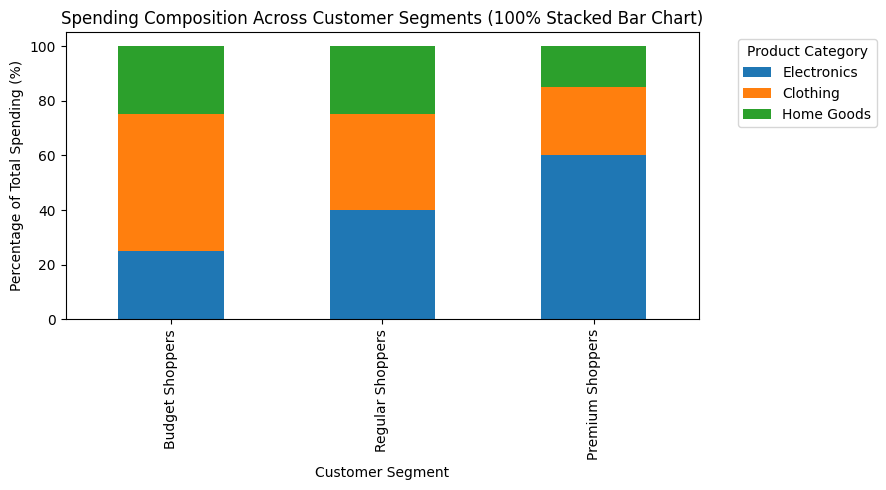

In [34]:


# -----------------------------
# Realistic dataset: customer spending composition
# -----------------------------
df_shop = pd.DataFrame({
    "Customer Segment": [
        "Budget Shoppers",
        "Regular Shoppers",
        "Premium Shoppers"
    ],
    "Electronics": [25, 40, 60],
    "Clothing": [50, 35, 25],
    "Home Goods": [25, 25, 15]
})

# -----------------------------
# Convert to percentage (row-wise normalization)
# -----------------------------
df_percent = df_shop.set_index("Customer Segment")
df_percent = df_percent.div(df_percent.sum(axis=1), axis=0) * 100

# -----------------------------
# Plot 100% stacked bar chart
# -----------------------------
ax = df_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Spending Composition Across Customer Segments (100% Stacked Bar Chart)")
plt.ylabel("Percentage of Total Spending (%)")
plt.xlabel("Customer Segment")
plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

In [36]:
# go back the previous example.
df.head()

,Study_Hours,Test_Score,Attendance_Pct,Previous_GPA,Gender
0,5.993428,92.559813,86.063100,3.926344,Female
1,4.723471,80.536699,88.030948,3.714668,Female
2,6.295377,86.061509,89.801805,3.517223,Male
3,8.046060,100.000000,90.988614,4.000000,Female
4,4.531693,90.906462,91.920187,3.906051,Male


## **Directly calculate the Pearson's correlations of variables**:

In [37]:
# calculate the pearson's correlation between two variables
corr_study_score = df.Study_Hours.corr(df.Test_Score, method = 'pearson')
print(f'Correlation between study hours and test score: {corr_study_score:.3f}')
# df.Test_Score.corr(df.Study_Hours, method = 'pearson')


Correlation between study hours and test score: 0.808


## **Correlation Heatmap - Visualizing Relationships Between Multiple Variables**

A **correlation heatmap** is a powerful visualization that displays the correlation coefficients between multiple variables in a color-coded matrix format. Each cell shows the strength and direction of the relationship between two variables using color intensity.

### What Does a Correlation Heatmap Show?

- **Pairwise Correlations**: Shows correlation between every pair of variables in your dataset
- **Relationship Strength**: Color intensity indicates how strongly two variables are related
- **Relationship Direction**: Color hue shows positive (warm colors) vs. negative (cool colors) correlations
- **Pattern Detection**: Quickly identifies which variables move together or inversely
- **Multicollinearity**: Helps detect when variables are too highly correlated (problem for some analyses)

### Why Use Correlation Heatmaps?

- **Comprehensive Overview**: See all variable relationships at once instead of checking pairs individually
- **Quick Insights**: Immediately spot strong positive/negative correlations
- **Feature Selection**: Helps choose which variables to use in predictive models
- **Data Understanding**: Reveals unexpected relationships in your data
- **Professional Presentation**: Creates publication-ready correlation visualizations

### When to Use:

- Exploring relationships in datasets with multiple numeric variables
- Before building regression or machine learning models (checking for multicollinearity)
- Identifying which variables to investigate further
- Comparing correlation patterns across different groups or time periods
- Presenting correlation analysis results in reports or papers

### Understanding Correlation Values:

- **+1.0**: Perfect positive correlation (variables move together perfectly)
- **+0.7 to +1.0**: Strong positive correlation
- **+0.3 to +0.7**: Moderate positive correlation
- **-0.3 to +0.3**: Weak or no correlation
- **-0.7 to -0.3**: Moderate negative correlation
- **-1.0 to -0.7**: Strong negative correlation
- **-1.0**: Perfect negative correlation (variables move in exact opposite directions)

### Key Parameters:

- `data`: Correlation matrix (typically from `df.corr()`)
- `annot=True`: Displays correlation values in each cell
- `cmap`: Color scheme ('coolwarm', 'RdBu', 'viridis', etc.)
- `center`: Value at which to center the colormap (usually 0 for correlations)
- `vmin`, `vmax`: Min/max values for color scale (default -1 to 1 for correlations)
- `square=True`: Makes cells square-shaped for better appearance
- `linewidths`: Adds spacing between cells
- `cbar_kws`: Customizes the color bar

### Best Practices:

1. **Use diverging colormap**: Choose colors that clearly show positive vs. negative (e.g., 'coolwarm', 'RdBu')
2. **Center at zero**: For correlations, center the color scale at 0
3. **Show values**: Set `annot=True` to display actual correlation numbers
4. **Consider size**: For many variables (>10), increase figure size or use smaller font
5. **Remove redundancy**: Optionally show only lower/upper triangle since matrix is symmetric

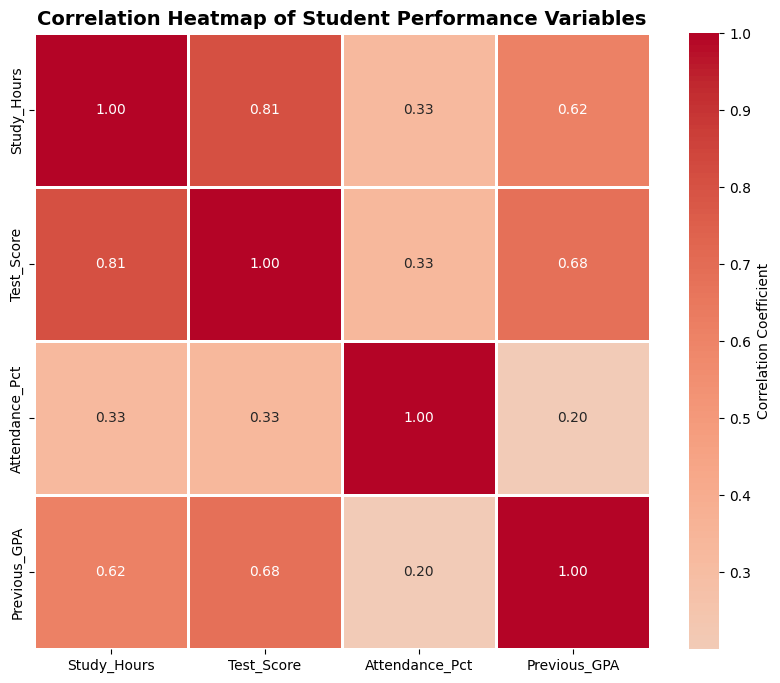

In [38]:
# Create a correlation heatmap to visualize relationships between all numeric variables

# Select only numeric columns for correlation analysis (excluding 'Gender' which is categorical)
numeric_df = df.select_dtypes(include=[np.number])

# calculate the pairwise pearson's correlation of multiple columns. 'r' is the correlation matrix calculated
r = numeric_df.corr()
r

# Set figure size for better readability
plt.figure(figsize=(10, 8))

# Create the heatmap
# center=0: Centers the color scale at 0 (important for correlations ranging from -1 to +1)
# cmap='coolwarm': Blue for negative correlations, red for positive correlations
# annot=True: Displays the correlation values in each cell
# fmt='.2f': Formats numbers to 2 decimal places
# square=True: Makes cells square-shaped for better appearance
# linewidths=1: Adds spacing between cells for clarity
sns.heatmap(r, center=0, cmap='coolwarm', annot=True, fmt='.2f',
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})

# Add title
plt.title('Correlation Heatmap of Student Performance Variables', fontsize=14, fontweight='bold')

# Display the plot
plt.show()

# Interpretation:
# - Values close to +1 (dark red): Strong positive correlation
# - Values close to -1 (dark blue): Strong negative correlation
# - Values close to 0 (white): Little to no correlation

## **Time Series Heatmap - Visualizing Patterns Over Time and Categories**

A **time series heatmap** displays data values as colors in a grid where one axis represents time periods and the other represents categories (like hours, days, or different variables). Color intensity shows the magnitude of values, making it easy to spot patterns, trends, and anomalies across time.

### What Does a Time Series Heatmap Show?

- **Temporal Patterns**: Reveals recurring patterns across time periods (daily cycles, weekly trends, seasonal variations)
- **Intensity Changes**: Shows when and where values are highest/lowest using color gradients
- **Anomalies**: Makes unusual spikes or drops immediately visible
- **Multi-dimensional Time Data**: Displays two time dimensions simultaneously (e.g., day of week vs. hour of day)
- **Comparative Trends**: Compares multiple time series side-by-side

### Why Use Time Series Heatmaps?

- **Pattern Recognition**: Quickly identify recurring patterns that would be hard to see in line charts
- **Dense Information**: Displays large amounts of time-based data in a compact format
- **Intuitive**: Color makes it easy to spot hot spots and cold spots at a glance
- **Multiple Variables**: Can show many time series simultaneously without clutter

### When to Use:

- Visualizing hourly patterns across days/weeks (website traffic by hour and day of week)
- Showing seasonal patterns (temperature by month and year)
- Analyzing cyclical behavior (sensor readings, user activity, sales patterns)
- Comparing time series across multiple categories (sales across products over time)
- Identifying when specific events occur (outages, peaks, anomalies)

### Common Use Cases:

1. **Website Analytics**: User activity by hour of day and day of week
2. **IoT/Sensor Data**: Temperature, humidity, or other measurements over time
3. **Financial Data**: Stock prices or trading volumes across time periods
4. **Operations**: Server load, response times, or system metrics
5. **Energy Consumption**: Electricity usage patterns by time of day and season
6. **Retail**: Sales patterns by hour/day/month

### Key Parameters:

- `data`: 2D array or DataFrame with time periods and categories
- `cmap`: Color palette ('YlGnBu', 'viridis', 'coolwarm', 'RdYlGn')
- `cbar`: Whether to show color bar legend (default True)
- `annot`: Whether to annotate cells with values (use for small heatmaps only)
- `linewidths`: Spacing between cells
- `vmin`, `vmax`: Set min/max values for color scale

### Best Practices:

1. **Choose intuitive colormaps**: Use sequential colormaps (light to dark) for values with one direction
2. **Orient time logically**: Typically time runs left-to-right (x-axis) or top-to-bottom (y-axis)
3. **Label clearly**: Make sure time periods and categories are clearly labeled
4. **Consider scale**: Use appropriate time granularity (don't show minutes when hours suffice)
5. **Handle missing data**: Decide how to display gaps (separate color, interpolation, or leave blank)

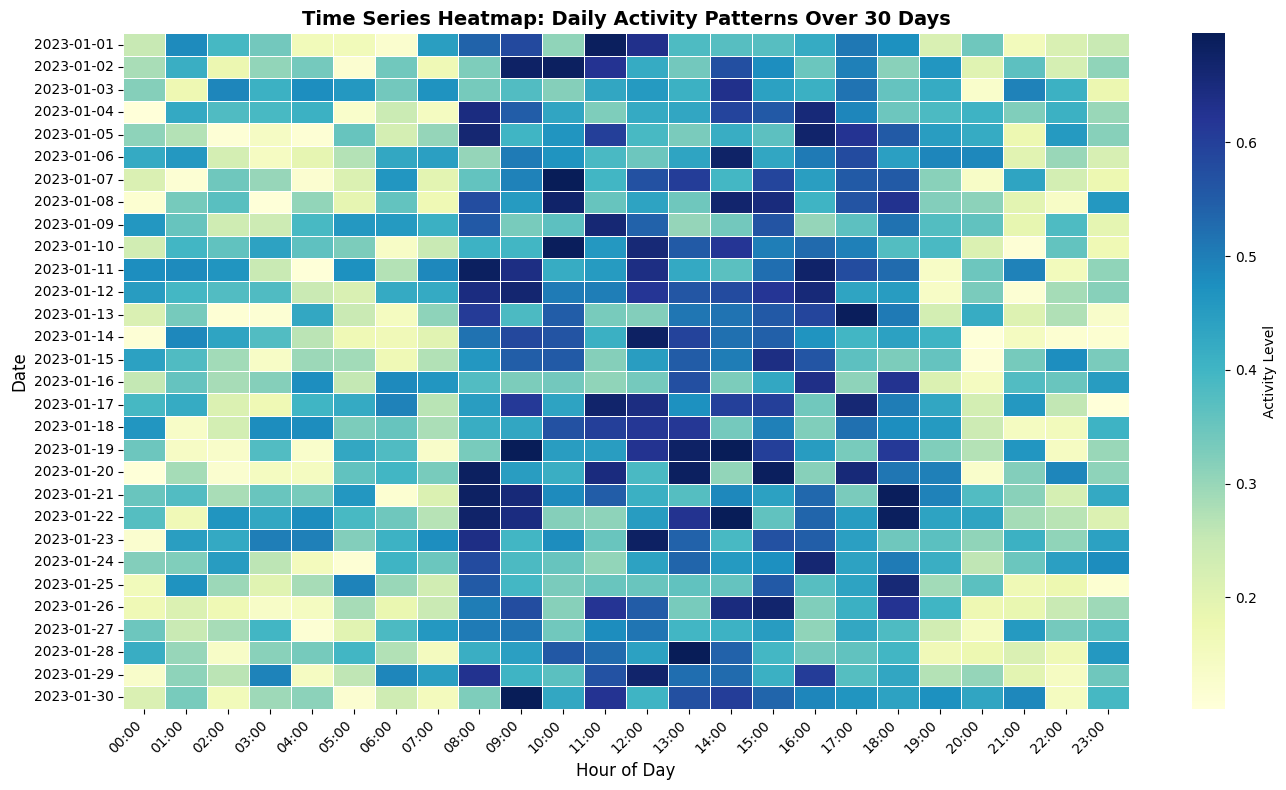

In [39]:
# Generate synthetic time series data for demonstration
# Simulating 30 days of hourly measurements (e.g., website traffic, temperature, etc.)

# Set random seed for reproducibility
np.random.seed(42)

# Create parameters
num_days = 30
hours_per_day = 24

# Generate synthetic data with some realistic patterns
# Adding daily cycle: higher values during certain hours (e.g., business hours)
data = np.zeros((num_days, hours_per_day))
for day in range(num_days):
    for hour in range(hours_per_day):
        # Create a pattern: higher activity during day hours (8am-6pm)
        base_value = 0.3 if (8 <= hour <= 18) else 0.1
        # Add random variation
        data[day, hour] = base_value + np.random.rand() * 0.4

# Convert to DataFrame with meaningful labels
# Rows = days, Columns = hours
df = pd.DataFrame(data, columns=[f'{i:02d}:00' for i in range(hours_per_day)])
df.index = pd.date_range(start='2023-01-01', periods=num_days, freq='D')
df.index = df.index.strftime('%Y-%m-%d')  # Format dates nicely

# Create the heatmap
plt.figure(figsize=(14, 8))

# cmap='YlGnBu': Yellow (low) to Green to Blue (high) - good for showing intensity
# cbar_kws: Customizes the color bar label
sns.heatmap(df, cmap='YlGnBu', cbar=True, linewidths=0.5,
            cbar_kws={'label': 'Activity Level'})

# Add descriptive labels and title
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Date', fontsize=12)
plt.title('Time Series Heatmap: Daily Activity Patterns Over 30 Days',
          fontsize=14, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Interpretation: Darker colors indicate higher values
# Look for patterns: Do certain hours consistently show higher activity?
# Are there any unusual days with different patterns?


## **Pairwise Scatter Plot (Scatter Matrix) - Exploring All Variable Relationships at Once**

A **pairwise scatter plot** (also called a scatter plot matrix or SPLOM) creates a grid of scatter plots showing the relationship between every pair of variables in your dataset. The diagonal typically shows the distribution of each individual variable, while off-diagonal cells show scatter plots between pairs.

### What Does a Pairwise Scatter Plot Show?

- **All Relationships**: Displays every possible two-variable relationship in one comprehensive view
- **Correlation Patterns**: Reveals which variable pairs are positively/negatively correlated or independent
- **Data Distribution**: Diagonal shows how each individual variable is distributed (histograms or KDE plots)
- **Grouping**: When color-coded by category, shows how different groups cluster in each dimension
- **Non-linear Relationships**: Identifies curves and non-linear patterns that correlation numbers might miss

### Why Use Pairwise Scatter Plots?

- **Comprehensive Exploration**: See all bivariate relationships without creating individual plots
- **Pattern Discovery**: Uncover unexpected relationships between variables
- **Quick Assessment**: Rapidly understand your dataset's structure and variable interactions
- **Feature Selection**: Identify which variables are most informative or redundant
- **Multi-class Comparison**: When colored by class labels, reveals which variable pairs best separate groups

### When to Use:

- Initial exploratory data analysis with multiple continuous variables (typically 3-10 variables)
- Before building machine learning models to understand feature relationships
- Checking for multicollinearity in regression analysis
- Comparing how different classes/categories differ across multiple dimensions
- Looking for patterns that might guide feature engineering

### Key Parameters:

#### Using pandas `scatter_matrix`:
- `frame`: Your DataFrame
- `c`: Color by a variable (e.g., categorical labels)
- `diagonal`: Type of plot on diagonal ('hist' for histogram, 'kde' for density)
- `figsize`: Size of the entire figure
- `alpha`: Transparency of points

#### Using seaborn `pairplot`:
- `data`: Your DataFrame
- `hue`: Column name to color points by groups
- `diag_kind`: 'hist' or 'kde' for diagonal plots
- `kind`: 'scatter' (default), 'reg' (with regression line), or 'kde'
- `palette`: Color scheme for different groups

### Best Practices:

1. **Limit variables**: Use 3-10 variables maximum. More than 10 creates a cluttered, hard-to-read plot
2. **Color by categories**: Use `hue` parameter to reveal how groups differ across all variable pairs
3. **Consider scale**: Standardize variables if they have very different ranges
4. **Use transparency**: Set `alpha < 1` when you have many points to see overlapping patterns
5. **Choose appropriate diagonal**: Use 'kde' for smoother distributions, 'hist' for discrete data
6. **Increase size**: Make the figure large enough to see details in individual subplots

### Interpretation Tips:

- **Strong linear pattern**: Indicates correlation between variables
- **Random scatter**: No clear relationship
- **Curved pattern**: Non-linear relationship
- **Distinct color clusters**: Groups separate well on those variables
- **Overlapping colors**: Groups are similar in those dimensions


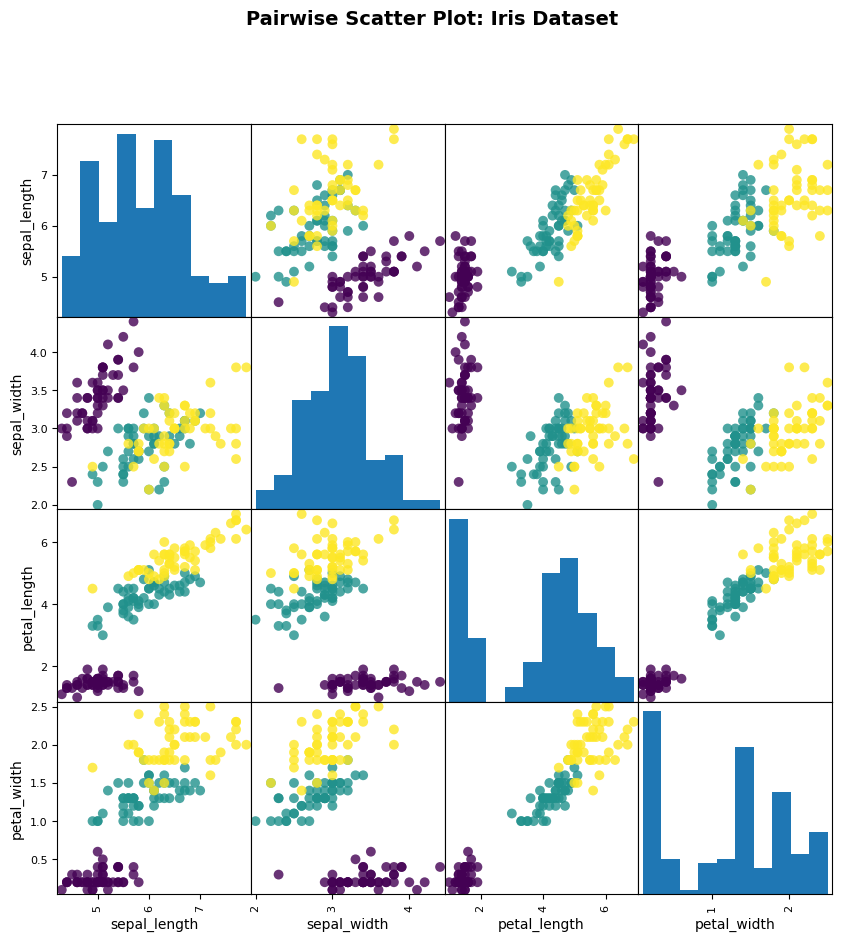

In [40]:
# Load the famous Iris dataset
# Contains measurements of 150 iris flowers from 3 species
iris = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")

# Create pairwise scatter plot using pandas
# This creates a grid showing every variable against every other variable
# Drop 'species' column for plotting (we'll use it for coloring)
# c=: Color points by species (converted to numeric codes)
# diagonal='hist': Show histograms on the diagonal instead of scatter plots
# alpha=0.8: Slight transparency to see overlapping points
# figsize: Large enough to see details in each subplot

pd.plotting.scatter_matrix(
    iris.drop('species', axis=1),  # Only numeric columns for plotting
    c=iris['species'].astype('category').cat.codes,  # Color by species
    figsize=(10, 10),
    diagonal='hist',  # Histograms show distribution of each variable
    alpha=0.8,
    marker='o',
    s=50  # Size of scatter points
)

plt.suptitle('Pairwise Scatter Plot: Iris Dataset', fontsize=14, fontweight='bold', y=0.995)

# Display the plot
plt.show()

# Interpretation:
# - Diagonal: Distribution of each individual feature
# - Off-diagonal: Relationships between pairs of features
# - Colors distinguish the three iris species
# - Look for patterns: Do certain species cluster together in specific feature pairs?

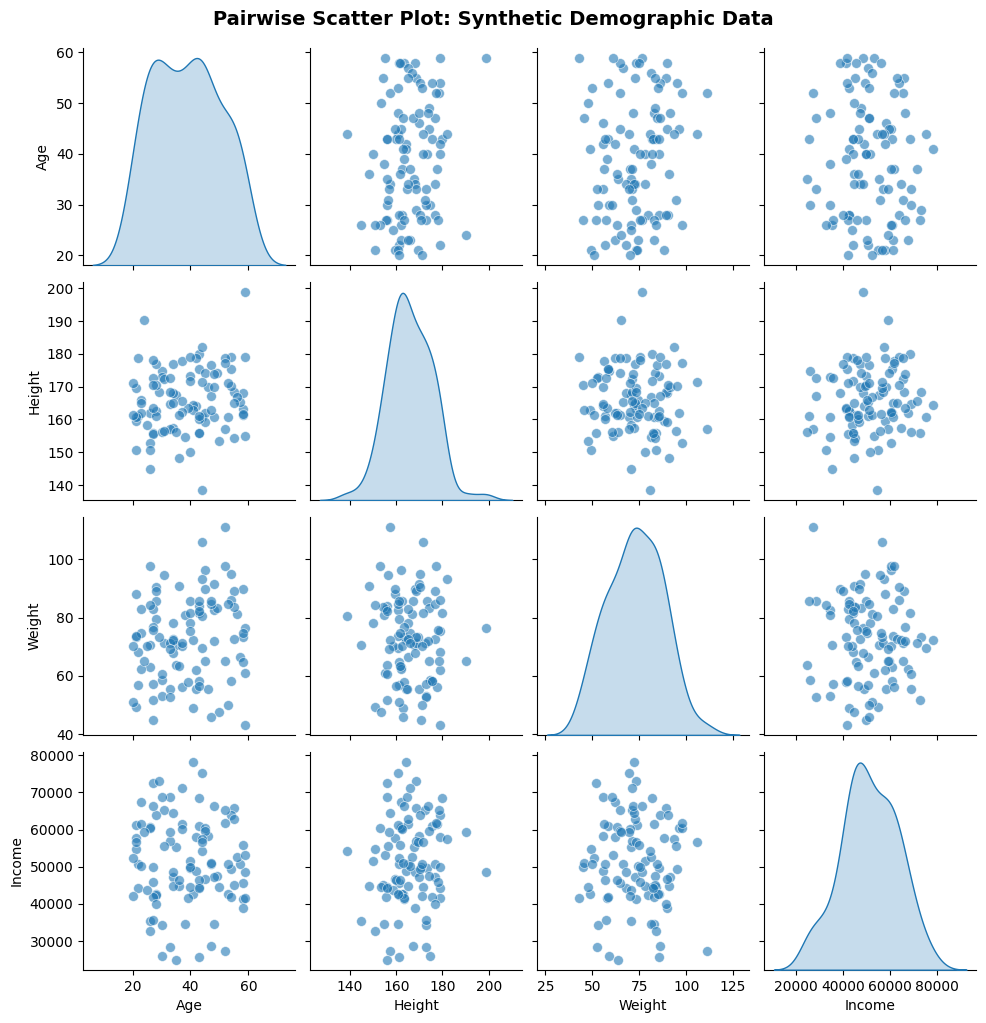

In [41]:
# Example 2: Seaborn's pairplot with synthetic data
# Seaborn's pairplot is more modern and offers additional features

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data representing people's characteristics
num_samples = 100
data = {
    "Age": np.random.randint(20, 60, size=num_samples),  # Age between 20 and 60
    "Height": np.random.normal(165, 10, size=num_samples),  # Height in cm (mean=165, std=10)
    "Weight": np.random.normal(70, 15, size=num_samples),  # Weight in kg (mean=70, std=15)
    "Income": np.random.normal(50000, 12000, size=num_samples)  # Income in USD
}

df_synthetic = pd.DataFrame(data)

# Create pairwise scatter plot using Seaborn
# diag_kind='kde': Shows smooth density curves on diagonal instead of histograms
# plot_kws: Customizes scatter plot appearance
#   - alpha=0.6: Transparency to see overlapping points
#   - s=50: Size of points
sns.pairplot(df_synthetic, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 50},
             corner=False)  # corner=False shows full matrix (not just lower triangle)

plt.suptitle('Pairwise Scatter Plot: Synthetic Demographic Data',
             y=1.02, fontsize=14, fontweight='bold')

plt.show()

# This visualization helps answer questions like:
# - Do taller people tend to weigh more? (Height vs Weight plot)
# - Does income increase with age? (Age vs Income plot)
# - How are all four variables distributed? (Diagonal plots)


## **Spider Chart (Radar Chart) - Comparing Multiple Variables on Different Scales**

A **spider chart** (also called a **radar chart**, **web chart**, or **star plot**) is a circular visualization that displays multivariate data on axes radiating from a central point. Each axis represents a different variable, and values are plotted as points connected by lines, forming a polygon shape.

### What Does a Spider Chart Show?

- **Multi-dimensional Profile**: Shows performance or characteristics across multiple metrics simultaneously
- **Relative Strengths**: Highlights which variables are stronger (farther from center) or weaker (closer to center)
- **Pattern Recognition**: Creates distinctive shapes that make profiles easy to compare visually
- **Balance**: Reveals whether an entity is well-rounded (circular shape) or specialized (irregular shape)
- **Multiple Entities**: Can overlay multiple subjects for direct comparison

### Why Use Spider Charts?

- **Holistic View**: See all metrics in one glance rather than separate charts
- **Visual Impact**: Distinctive shape is memorable and eye-catching
- **Profile Comparison**: Compare entities (products, people, teams) across multiple dimensions
- **Relative Performance**: Shows which areas need improvement and which are strengths
- **Dashboard Appeal**: Compact and visually appealing for presentations and reports

### When to Use:

- **Performance Analysis**:
  - Employee evaluations across different skill areas
  - Sports player statistics (speed, strength, accuracy, etc.)
  - Product features comparison (price, quality, durability, etc.)
  - Company metrics (sales, customer satisfaction, innovation, etc.)

- **Quality Assessment**:
  - Software quality metrics (reliability, usability, performance, etc.)
  - Service quality dimensions
  - Health metrics (physical fitness, nutrition, sleep, etc.)

- **Competitive Analysis**:
  - Comparing competitors across multiple factors
  - Market positioning
  - Feature comparison matrices

### Key Components:

1. **Central Point**: Represents zero or minimum value
2. **Radial Axes**: Each spoke represents a different variable/metric
3. **Polygons**: Filled or outlined shapes connecting data points
4. **Scale**: Distance from center indicates magnitude
5. **Labels**: Variable names at the end of each axis

### Key Parameters:

- `theta`: Array of angles for each axis (evenly spaced around 360°)
- `values`: Data values for each variable
- `ax`: Polar subplot for plotting
- `linewidth`: Thickness of the connecting lines
- `alpha`: Transparency of filled area
- `color`: Color for the line and/or fill

### Best Practices:

1. **Limit variables**: Use 3-10 variables. Too many (>12) makes the chart cluttered and hard to read
2. **Normalize scales**: Convert all variables to the same scale (0-100 or z-scores) since axes share the same radial distance
3. **Use consistently**: All variables should be oriented the same way (higher values = better, or all same meaning)
4. **Add multiple subjects**: Overlay 2-4 profiles for comparison, using different colors
5. **Make it readable**: Ensure axis labels are clear and don't overlap
6. **Close the polygon**: Connect the last point back to the first for a complete shape

### When NOT to Use:

- **Don't use spider charts when:**
  - Variables are on very different scales and can't be normalized
  - Precise value reading is important (bar charts are better)
  - You have many variables (>12) - becomes unreadable
  - Variables have no logical ordering
  - Audience is unfamiliar with this chart type
  - Comparing more than 4-5 entities (overlapping polygons become confusing)

### Limitations:

1. **Hard to read exact values**: Distance estimation is imprecise
2. **Area bias**: Human eyes judge area, which can be misleading
3. **Ordering effects**: Adjacent variables appear more related
4. **Not for everyone**: Less familiar chart type than bars or lines

### Alternative:
For many variables or precise comparisons, consider using **parallel coordinates plots** or **grouped bar charts** instead!

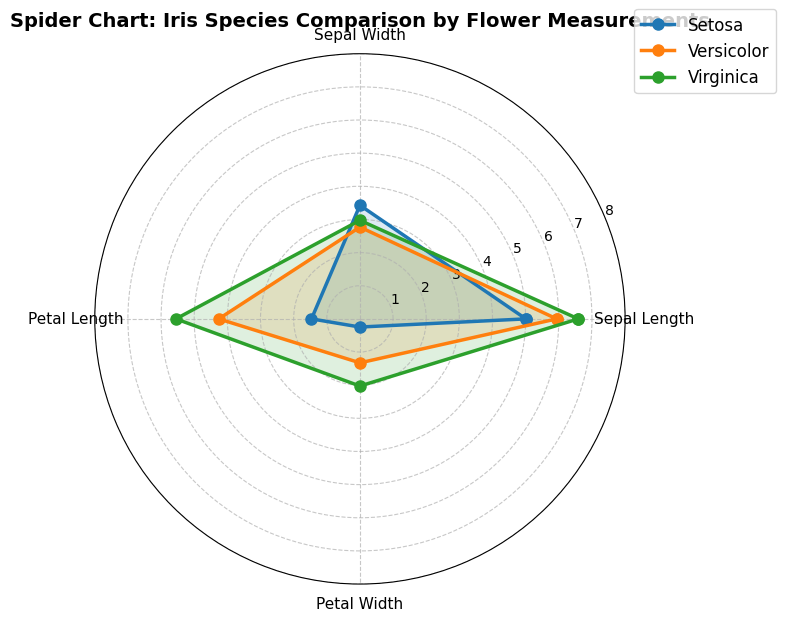

In [42]:
# SPIDER CHART EXAMPLE: Comparing Iris Flower Species
# This example uses the famous iris dataset to compare three species of iris flowers
# across four key measurements

# Load the iris dataset from sklearn
# The iris dataset contains measurements of 150 iris flowers from three species
iris_data = load_iris()

# Convert to DataFrame for easier manipulation
# Columns: sepal length, sepal width, petal length, petal width
iris = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
iris['species'] = iris_data.target

# Map species numbers to names for better readability
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
iris['species'] = iris['species'].map(species_map)

# Calculate mean values for each species (to show their characteristic profiles)
# This gives us the "average" flower measurements for each species
species_means = iris.groupby('species').mean()

# The four metrics (axes) are: Sepal Length, Sepal Width, Petal Length, Petal Width
metrics = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
species_names = species_means.index.tolist()  # ['setosa', 'versicolor', 'virginica']

# Set up the radar chart geometry
num_metrics = len(metrics)  # Number of metrics (4 in this case)

# Create evenly spaced angles for each axis (in radians)
# endpoint=False means we don't duplicate the starting angle
theta = np.linspace(0, 2*np.pi, num_metrics, endpoint=False)

# Close the polygon by appending the first angle at the end
theta = np.concatenate((theta, [theta[0]]))

# Create the polar plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, polar=True)  # polar=True creates a circular plot

# Plot each species as a separate polygon
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

for i, species in enumerate(species_names):
    # Get the mean values for this species across all 4 metrics
    values = species_means.loc[species].values

    # Close the polygon by appending the first value at the end
    values = np.concatenate((values, [values[0]]))

    # Plot the line connecting all points
    ax.plot(theta, values, linewidth=2.5, linestyle='solid',
            label=species.capitalize(), color=colors[i], marker='o', markersize=8)

    # Fill the area inside the polygon with transparency
    ax.fill(theta, values, alpha=0.15, color=colors[i])

# Customize the plot
ax.set_xticks(theta[:-1])  # Set tick positions (exclude the duplicate last point)
ax.set_xticklabels(['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width'],
                   fontsize=11)
ax.set_ylim(0, 8)  # Set radial axis limits to accommodate the data range
ax.grid(True, linestyle='--', alpha=0.7)

# Add legend and title
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.set_title('Spider Chart: Iris Species Comparison by Flower Measurements',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Interpretation:
# - Each colored polygon represents one iris species (Setosa, Versicolor, Virginica)
# - Points farther from the center indicate larger measurements
# - Setosa (blue): Has shorter petals but relatively wider sepals - creates a distinctive shape
# - Versicolor (orange): Intermediate measurements - the "middle" species
# - Virginica (green): Largest overall measurements, especially petal length - largest polygon
# - The different shapes make it easy to see how these species differ from each other
#
# Key Insights:
# - Petal length and width are the most distinctive features (biggest differences)
# - Setosa has notably smaller petals compared to the other two species
# - Virginica tends to have the largest flowers overall

## **Parallel Coordinates Plot - Visualizing High-Dimensional Data**

A **parallel coordinates plot** is a powerful technique for visualizing multivariate data where each variable is represented as a vertical axis, and each data observation is shown as a line connecting its values across all axes. This creates a "flow" that reveals patterns in high-dimensional space.

### What Does a Parallel Coordinates Plot Show?

- **Multi-dimensional Relationships**: Displays how variables are related across many dimensions simultaneously
- **Patterns and Clusters**: Lines that follow similar paths indicate observations with similar characteristics
- **Correlations**: Parallel lines between axes suggest positive correlation, crossing lines suggest negative correlation
- **Outliers**: Lines that deviate significantly from the main bundle are unusual observations
- **Class Separation**: When colored by category, shows which variable combinations separate groups

### Why Use Parallel Coordinates Plots?

- **High-Dimensional**: Can display 5-20+ variables in one visualization (impossible with scatter plots)
- **Relationship Detection**: Reveals complex relationships between multiple variables
- **Filtering**: Interactive versions allow selecting specific patterns to explore
- **Anomaly Detection**: Unusual patterns stand out visually
- **Feature Selection**: Helps identify which variables distinguish between classes

### When to Use:

- **Data Exploration**: Initial exploration of datasets with many numeric features
- **Machine Learning**: Understanding feature relationships in classification/clustering problems
- **Quality Control**: Monitoring multiple parameters simultaneously (manufacturing, systems)
- **Optimization**: Visualizing trade-offs in multi-objective optimization
- **Comparison**: Comparing multiple entities across numerous attributes

### Key Components:

1. **Vertical Axes**: Each axis represents one variable, typically standardized to the same scale
2. **Lines**: Each line represents one observation, connecting its values across all axes
3. **Color**: Often used to distinguish between classes or groups
4. **Axis Order**: Variables can be reordered to reveal different patterns

### Understanding Patterns:

- **Parallel Lines Between Two Axes**: Positive correlation
- **Crossing Lines (X pattern)**: Negative correlation
- **Bundle of Lines**: Cluster of similar observations
- **Isolated Lines**: Outliers or unusual cases
- **Color Separation**: Axes where colors separate well are discriminative features

### Key Parameters:

- `frame`: DataFrame containing the data
- `class_column`: Column name to use for coloring the lines (typically the target variable)
- `cols`: Specific columns to include (if you don't want all variables)
- `color` or `colormap`: Color scheme for different classes
- `alpha`: Transparency (useful when many lines overlap)
- `axvlines`: Whether to show vertical axis lines

### Best Practices:

1. **Standardize scales**: Normalize variables to 0-1 or z-scores since they share vertical space
2. **Limit variables**: 4-15 variables work best. Too many becomes cluttered
3. **Order strategically**: Place correlated variables next to each other to reduce line crossings
4. **Use color**: Color by categorical variable to reveal class patterns
5. **Add transparency**: Use alpha < 1 to see overlapping lines
6. **Interactive exploration**: Use interactive tools (like Plotly) for large datasets to enable filtering

### When NOT to Use:

- Very small datasets (<20 observations) - other plots might be more appropriate
- When precise value reading is critical - hard to read exact values on parallel axes
- For non-technical audiences unfamiliar with the visualization type
- When you have both categorical and continuous variables mixed (works best with all continuous)

### Advantages:

- ✓ Handles many variables (10-20+)
- ✓ Reveals complex patterns
- ✓ Good for clustering and classification visualization
- ✓ Compact representation

### Limitations:

- ✗ Can become cluttered with many observations (use transparency/sampling)
- ✗ Axis ordering matters (different orders show different patterns)
- ✗ Harder to interpret than simpler plots
- ✗ Overlapping lines can hide patterns

### Common Applications:

- **Machine Learning**: Visualizing feature space in classification problems
- **Process Control**: Monitoring multiple sensors or quality metrics
- **Finance**: Comparing stocks or portfolios across multiple metrics
- **Healthcare**: Patient profiles across multiple measurements

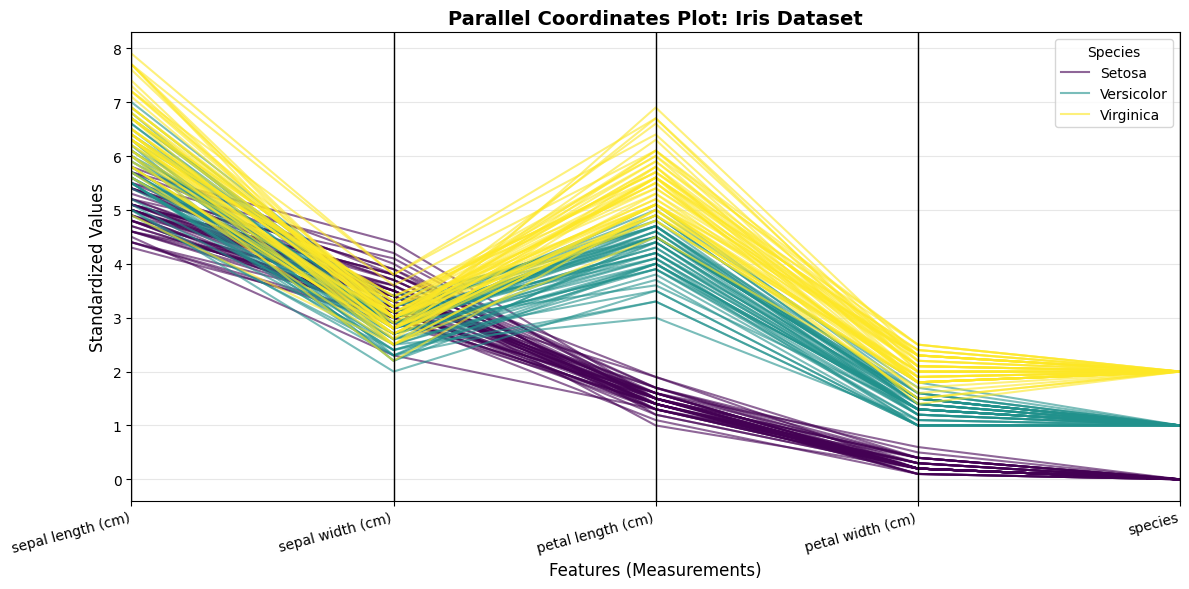

In [43]:
# Load the famous Iris dataset
# Contains 4 measurements for 150 iris flowers from 3 different species
iris = load_iris()

# Create a DataFrame with the feature data
# Each row is one flower, each column is one measurement
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target variable (species: 0=setosa, 1=versicolor, 2=virginica)
df_iris['species'] = iris.target

# Map numeric targets to species names for better legend
species_map = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
df_iris['species_name'] = df_iris['species'].map(species_map)

# Create the parallel coordinates plot
# Each line represents one flower
# Lines are colored by species
# Each vertical axis represents one of the four measurements

plt.figure(figsize=(12, 6))

# Create parallel coordinates plot
# class_column: The column to use for coloring (species_name)
# colormap: Color scheme for the three species
parallel_coordinates(df_iris, 'species_name', colormap='viridis', alpha=0.6)

# Customize the plot
plt.title('Parallel Coordinates Plot: Iris Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Features (Measurements)', fontsize=12)
plt.ylabel('Standardized Values', fontsize=12)
plt.legend(title='Species', loc='upper right')
plt.grid(axis='y', alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.show()

# Interpretation:
# - Each colored line represents one flower
# - Follow a line across all four axes to see that flower's measurements
# - Lines that follow similar paths are similar flowers
# - Notice how Setosa (purple) separates clearly from the other species
# - Look for patterns: Do certain species have consistently higher/lower values on specific features?
# - Crossing lines between axes suggest negative correlation


## **Time Series Visualization - Tracking Changes Over Time**

A **time series visualization** displays data points collected sequentially over time, typically using a line chart. Time is plotted on the x-axis and the measured variable on the y-axis, creating a visual story of how values change across temporal periods.

### What Does a Time Series Visualization Show?

- **Trends**: Overall upward, downward, or stable patterns over time (long-term direction)
- **Seasonality**: Regular, predictable patterns that repeat at fixed intervals (daily, weekly, monthly, yearly)
- **Cyclical Patterns**: Longer-term oscillations not tied to fixed calendar periods
- **Volatility**: How much values fluctuate around the trend
- **Anomalies**: Unusual spikes, drops, or deviations from normal patterns
- **Turning Points**: When trends change direction

### Why Use Time Series Visualizations?

- **Trend Analysis**: Identify whether things are improving, declining, or staying constant
- **Forecasting**: Visual patterns help predict future values
- **Anomaly Detection**: Spots unusual events that need investigation (equipment failures, market crashes, etc.)
- **Comparison**: Compare current performance against historical patterns
- **Communication**: Makes temporal changes immediately understandable

### When to Use:

- **Any data collected over time**:
  - Stock prices, sales figures, revenue
  - Temperature, weather patterns, climate data
  - Website traffic, user activity, system metrics
  - Patient vital signs, medical measurements
  - Economic indicators, population growth
  - Social media metrics, engagement rates

- **Key Questions Answered**:
  - Is performance improving or declining?
  - Are there seasonal patterns?
  - When did significant changes occur?
  - What is the normal range vs. anomalies?

### Common Time Series Patterns:

1. **Trend**: Long-term increase or decrease
   - Uptrend: Values generally increasing over time
   - Downtrend: Values generally decreasing over time
   - Flat: No clear directional movement

2. **Seasonality**: Regular patterns repeating at fixed intervals
   - Daily: Peak hours during the day
   - Weekly: Weekday vs. weekend patterns
   - Monthly: End-of-month effects
   - Yearly: Summer vs. winter, holiday seasons

3. **Cycles**: Irregular oscillations (business cycles, boom-bust)

4. **Volatility**: Degree of variation
   - High volatility: Rapid, large changes
   - Low volatility: Stable, small changes

5. **Structural Breaks**: Sudden permanent changes in pattern

### Key Parameters:

- `x`: Time variable (dates, timestamps, periods)
- `y`: Measured variable
- `color`: Line color
- `linewidth` or `lw`: Thickness of the line
- `linestyle` or `ls`: Solid, dashed, dotted, etc.
- `marker`: Add points at data values
- `alpha`: Transparency

### Best Practices:

1. **Always label time axis**: Make dates/times clear with appropriate format
2. **Choose appropriate time scale**: Match granularity to your data (hourly, daily, monthly, etc.)
3. **Start y-axis at meaningful value**: Not always zero - depends on context
4. **Add reference lines**: Mark important events, targets, or thresholds
5. **Handle missing data**: Decide whether to show gaps, interpolate, or mark explicitly
6. **Consider multiple series**: Compare related time series on the same plot
7. **Add annotations**: Label significant events or anomalies
8. **Use appropriate date formatting**: Make time labels readable without overlap

### Enhanced Visualizations:

- **Moving Averages**: Add smoothed trend lines to reduce noise
- **Confidence Intervals**: Show uncertainty bands around predictions
- **Multiple Series**: Compare multiple related metrics
- **Dual Axis**: Plot series with different scales together
- **Highlighted Regions**: Shade important time periods (recessions, campaigns, etc.)

### Common Mistakes to Avoid:

1. ✗ Improper time scale (daily data shown as monthly)
2. ✗ Missing data not handled transparently
3. ✗ Too many overlapping lines (use faceting instead)
4. ✗ Inappropriate y-axis scaling that exaggerates/minimizes changes
5. ✗ Not accounting for seasonality when detecting trends

### Tools and Techniques:

- **Line plots**: Standard for continuous time series
- **Step plots**: For discrete changes (price changes, state transitions)
- **Area plots**: Emphasize magnitude and cumulative totals
- **Candlestick charts**: For financial data (open/high/low/close)
- **Seasonal decomposition**: Separate trend, seasonal, and residual components

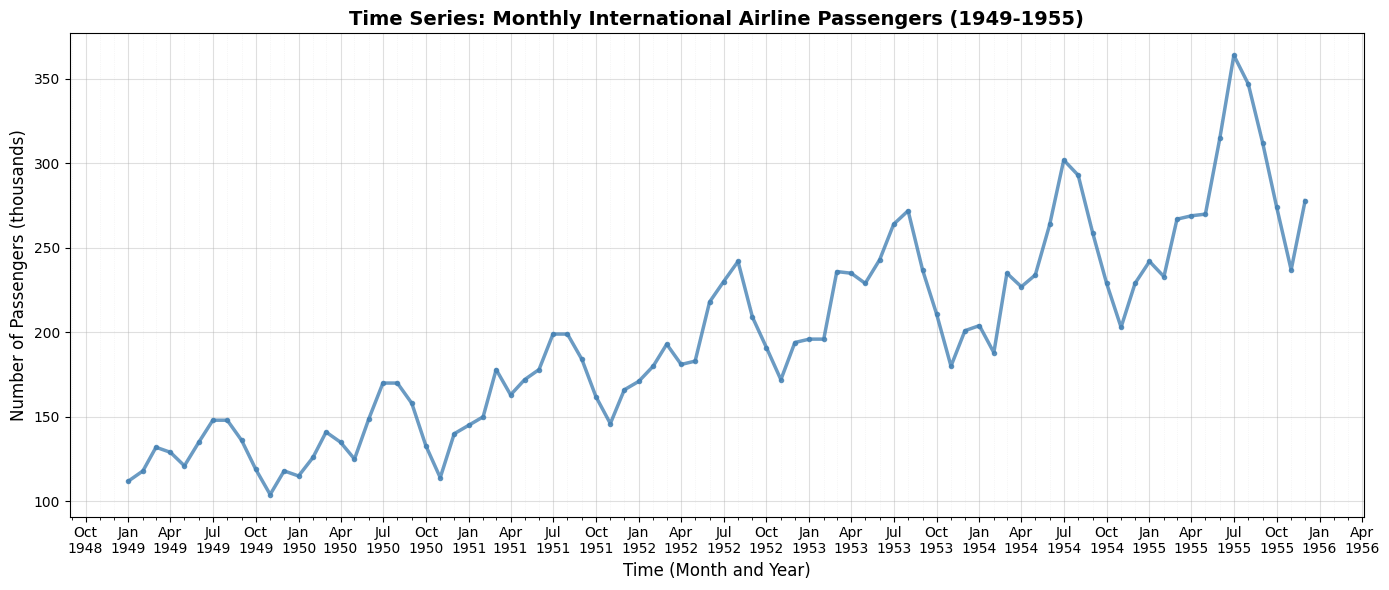

In [44]:
# Load historical airline passenger data (1949-1960)
# This is a classic time series dataset showing monthly international airline passengers
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'

# parse_dates: Converts 'Month' column to datetime objects
# index_col: Sets 'Month' as the index for easier time series operations
data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Filter data to show only 1949-1955
data = data.loc['1949':'1955']

# Import date formatting tools for better x-axis display
import matplotlib.dates as mdates

# Create the time series plot
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the data as a line chart
# x-axis: Time (Month), y-axis: Number of passengers
ax.plot(data.index, data['Passengers'], color='steelblue', linewidth=2.5,
        marker='o', markersize=3, alpha=0.8)

# Format x-axis to show month abbreviations (Jan, Feb, etc.)
# MonthLocator: Places ticks at each month
# DateFormatter: Formats the date labels
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Show every 3 months to avoid crowding
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))  # Format: Jan\n1949

# Add minor ticks for each month (creates monthly grid lines)
ax.xaxis.set_minor_locator(mdates.MonthLocator())

# Add labels and title with descriptive information
ax.set_xlabel('Time (Month and Year)', fontsize=12)
ax.set_ylabel('Number of Passengers (thousands)', fontsize=12)
ax.set_title('Time Series: Monthly International Airline Passengers (1949-1955)',
             fontsize=14, fontweight='bold')

# Add a grid for easier reading of values
# Major grid: For labeled months (every 3 months)
ax.grid(True, which='major', alpha=0.4, linestyle='-', linewidth=0.8)
# Minor grid: For all months (creates monthly gridlines)
ax.grid(True, which='minor', alpha=0.2, linestyle=':', linewidth=0.5)

# Rotate x-axis labels for better readability
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')

plt.tight_layout()
plt.show()

# Interpretation:
# - Clear UPWARD TREND: Passenger numbers increase over the 7-year period (1949-1955)
# - SEASONALITY: Regular yearly patterns - peaks in summer, dips in winter
# - INCREASING VARIANCE: The seasonal swings get larger over time
# - No major anomalies or structural breaks
# - The monthly gridlines make it easy to track specific months and see seasonal patterns
# This pattern (trend + seasonality + increasing variance) is common in economic data!


## What is a Log-Log Plot?

A **log-log plot** is a graph where **both the x-axis and y-axis use logarithmic scales** instead of regular (linear) scales.

In a normal plot, equal distances represent equal differences.  
In a log-log plot, equal distances represent **multiplication** (e.g., 10 → 100 → 1000).



## Why do we use log-log plots?

Log-log plots are useful when:

- Data values vary **a lot** (from very small to very large)
- You want to study **patterns in growth**
- You suspect a **power-law relationship**, like:

  y = a · x^b


## Key idea

If a relationship follows a power law:

- It looks **curved** in a normal plot  
- It becomes a **straight line** in a log-log plot

This makes patterns easier to see and analyze.



## Example situations

Log-log plots are commonly used in:

- Population growth studies  
- Earthquake magnitudes  
- Income distributions  
- Word frequencies in language  
- Internet and social networks  


## Important notes

- You **cannot use log scale with zero or negative values**
- Log-log plots are best when data spans **multiple orders of magnitude**
- They help reveal patterns, but may be **less intuitive at first glance**



## Simple intuition

Think of it like zooming out on both axes so you can see the **big picture structure** of the data instead of just small details.

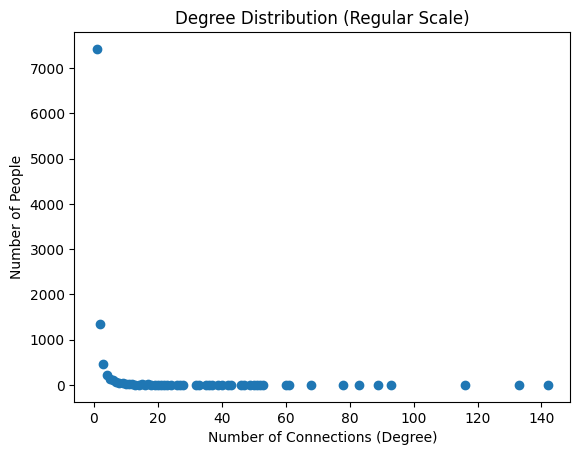

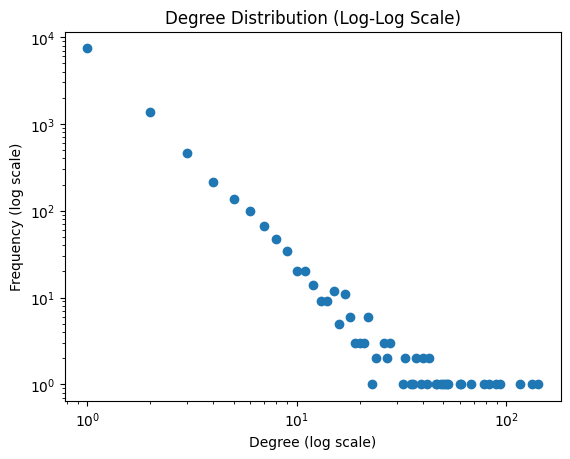

In [45]:


# Simulate a social network degree distribution using Zipf (power-law-like)
np.random.seed(42)
degrees = np.random.zipf(a=2.5, size=10000)

# Count how many nodes have each degree
values, counts = np.unique(degrees, return_counts=True)

# --- Regular plot ---
plt.figure()
plt.scatter(values, counts)
plt.title("Degree Distribution (Regular Scale)")
plt.xlabel("Number of Connections (Degree)")
plt.ylabel("Number of People")
plt.show()

# --- Log-Log plot ---
plt.figure()
plt.scatter(values, counts)
plt.xscale("log")
plt.yscale("log")
plt.title("Degree Distribution (Log-Log Scale)")
plt.xlabel("Degree (log scale)")
plt.ylabel("Frequency (log scale)")
plt.show()

## **Chi-Square Test - Testing Independence Between Categorical Variables**

The **Chi-Square Test of Independence** is a statistical hypothesis test used to determine whether two categorical variables are associated (dependent) or independent of each other.

### What Does the Chi-Square Test Do?

The test compares **observed frequencies** (actual counts in your data) with **expected frequencies** (counts you would expect if the variables were completely independent). If the observed and expected frequencies differ significantly, we conclude that the variables are associated.

### Why Use the Chi-Square Test?

- **Test Relationships**: Determine if there's a significant association between two categorical variables
- **Decision Making**: Answer questions like "Does gender affect reading preferences?" or "Is treatment outcome related to patient age group?"
- **Statistical Rigor**: Provides a p-value to quantify the strength of evidence against independence
- **Widely Applicable**: Works with any categorical data (gender, preferences, outcomes, categories)

### When to Use:

- **Survey Analysis**: Testing if responses differ by demographic groups
- **Medical Studies**: Checking if treatment outcomes differ by patient characteristics
- **Market Research**: Determining if product preferences vary by customer segments
- **A/B Testing**: Evaluating if different versions lead to different user behaviors

### How to Interpret:

1. **Chi-Square Statistic (χ²)**: Measures how much observed data deviates from expected
   - Larger values = stronger evidence of association
   - Smaller values = data consistent with independence

2. **P-value**: Probability of observing this data if variables were truly independent
   - **p < 0.05**: Strong evidence of association (reject independence hypothesis)
   - **p ≥ 0.05**: Insufficient evidence to conclude association (fail to reject independence)

3. **Critical Value**: The chi-square threshold for a given significance level
   - If χ² > critical value → reject independence

### Example Scenario:

A bookstore wants to know: **"Is book genre preference (fiction vs. non-fiction) associated with reader gender?"**

This is the perfect case for a chi-square test because we have two categorical variables:
- **Variable 1**: Gender (Male, Female)
- **Variable 2**: Book Preference (Fiction, Non-Fiction)

CONTINGENCY TABLE: Observed Frequencies
             Male  Female
Fiction       250     200
Non-Fiction    50    1000

Row Totals: [ 450 1050] (Fiction, Non-Fiction)
Column Totals: [ 300 1200] (Male, Female)
Grand Total: 1500 readers surveyed


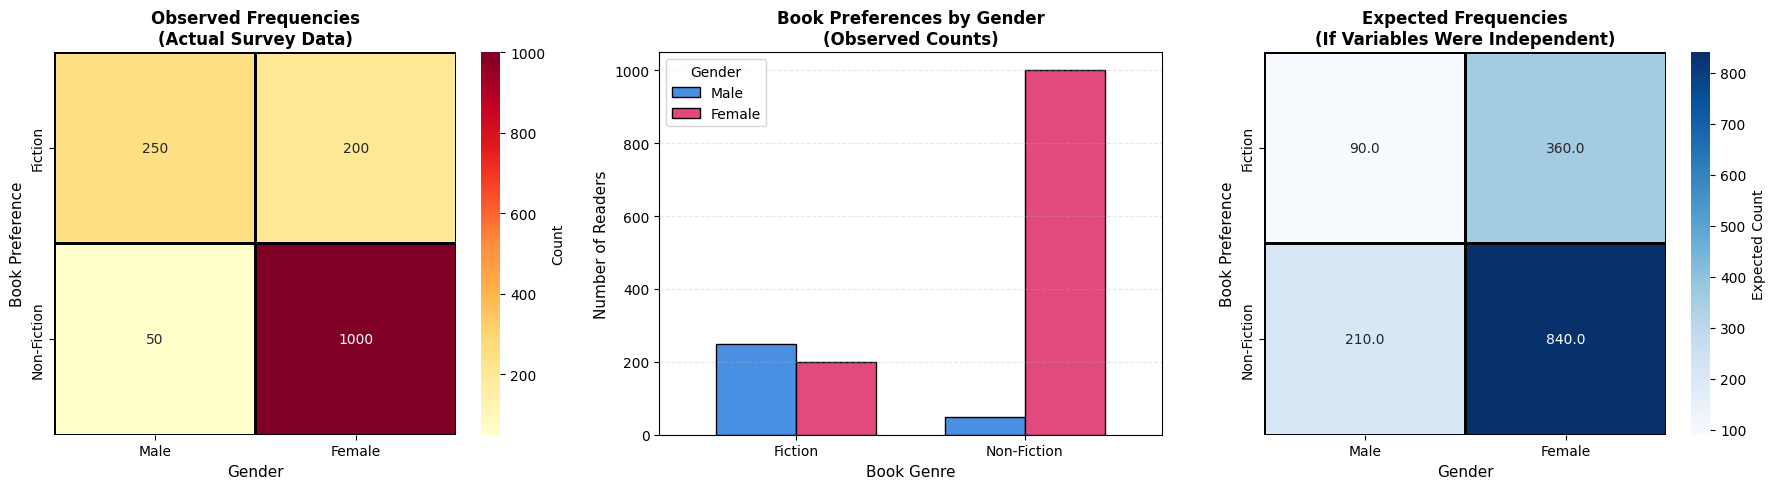


CHI-SQUARE TEST RESULTS
Chi-Square Statistic (χ²): 504.7669
P-value: 0.000000
Degrees of Freedom: 1

Significance Level: α = 0.05
Critical Value at α=0.05: 3.8415

INTERPRETATION
✓ REJECT the null hypothesis (independence)
  → The p-value (0.000000) is less than 0.05
  → The χ² statistic (504.7669) exceeds the critical value (3.8415)

  CONCLUSION: Gender and book preference ARE associated!
  There is a statistically significant relationship between gender and reading preferences.

KEY INSIGHTS FROM THE DATA
• Males: 83.3% prefer fiction (250/300), 16.7% prefer non-fiction (50/300)
• Females: 16.7% prefer fiction (200/1200), 83.3% prefer non-fiction (1000/1200)
• The distribution patterns differ dramatically between genders!
• Observed frequencies deviate significantly from expected frequencies
• This strong association is reflected in the very high χ² value and very low p-value


In [46]:
# CHI-SQUARE TEST EXAMPLE: Book Genre Preference by Gender
# Testing if gender and book preference are independent

# Step 1: Create the contingency table (observed frequencies)
# This table shows the actual counts from our bookstore survey
# Rows: Book genres (Fiction, Non-Fiction)
# Columns: Reader gender (Male, Female)

data = pd.DataFrame({
    'Male': [250, 50],      # 250 males prefer fiction, 50 prefer non-fiction
    'Female': [200, 1000]   # 200 females prefer fiction, 1000 prefer non-fiction
}, index=['Fiction', 'Non-Fiction'])

print("CONTINGENCY TABLE: Observed Frequencies")
print("=" * 50)
print(data)
print("\nRow Totals:", data.sum(axis=1).values, "(Fiction, Non-Fiction)")
print("Column Totals:", data.sum(axis=0).values, "(Male, Female)")
print("Grand Total:", data.sum().sum(), "readers surveyed")

# Step 2: Visualize the contingency table as a heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Heatmap of observed counts
sns.heatmap(data, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'},
            ax=axes[0], linewidths=1, linecolor='black')
axes[0].set_title('Observed Frequencies\n(Actual Survey Data)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Book Preference', fontsize=11)

# Subplot 2: Grouped bar chart for comparison
data.plot(kind='bar', ax=axes[1], color=['#4A90E2', '#E24A7F'], width=0.7, edgecolor='black')
axes[1].set_title('Book Preferences by Gender\n(Observed Counts)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Book Genre', fontsize=11)
axes[1].set_ylabel('Number of Readers', fontsize=11)
axes[1].set_xticklabels(['Fiction', 'Non-Fiction'], rotation=0)
axes[1].legend(title='Gender', fontsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Step 3: Perform the Chi-Square Test of Independence
chi_stat, p_value, degrees_freedom, expected_freq = chi2_contingency(data)

# Create expected frequencies DataFrame for visualization
expected = pd.DataFrame(expected_freq,
                        index=data.index,
                        columns=data.columns)

# Subplot 3: Heatmap of expected frequencies (if independent)
sns.heatmap(expected, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Expected Count'},
            ax=axes[2], linewidths=1, linecolor='black')
axes[2].set_title('Expected Frequencies\n(If Variables Were Independent)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Gender', fontsize=11)
axes[2].set_ylabel('Book Preference', fontsize=11)

plt.tight_layout()
plt.show()

# Step 4: Display test results
print("\n" + "=" * 50)
print("CHI-SQUARE TEST RESULTS")
print("=" * 50)
print(f"Chi-Square Statistic (χ²): {chi_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of Freedom: {degrees_freedom}")
print(f"\nSignificance Level: α = 0.05")

# Get critical value for 95% confidence (α = 0.05)
critical_value = chi2.ppf(0.95, degrees_freedom)
print(f"Critical Value at α=0.05: {critical_value:.4f}")

# Step 5: Interpret the results
print("\n" + "=" * 50)
print("INTERPRETATION")
print("=" * 50)

if p_value < 0.05:
    print("✓ REJECT the null hypothesis (independence)")
    print(f"  → The p-value ({p_value:.6f}) is less than 0.05")
    print(f"  → The χ² statistic ({chi_stat:.4f}) exceeds the critical value ({critical_value:.4f})")
    print("\n  CONCLUSION: Gender and book preference ARE associated!")
    print("  There is a statistically significant relationship between gender and reading preferences.")
else:
    print("✗ FAIL TO REJECT the null hypothesis")
    print(f"  → The p-value ({p_value:.6f}) is greater than 0.05")
    print(f"  → The χ² statistic ({chi_stat:.4f}) is below the critical value ({critical_value:.4f})")
    print("\n  CONCLUSION: Cannot conclude that gender and book preference are associated.")
    print("  The data is consistent with independence.")

print("\n" + "=" * 50)
print("KEY INSIGHTS FROM THE DATA")
print("=" * 50)
print("• Males: 83.3% prefer fiction (250/300), 16.7% prefer non-fiction (50/300)")
print("• Females: 16.7% prefer fiction (200/1200), 83.3% prefer non-fiction (1000/1200)")
print("• The distribution patterns differ dramatically between genders!")
print("• Observed frequencies deviate significantly from expected frequencies")
print("• This strong association is reflected in the very high χ² value and very low p-value")

## **Data Cleaning Techniques - Encoding Categorical Data & Boolean Filtering**

Data cleaning is one of the most critical steps in data analysis. Real-world data often contains categorical labels (like "good", "fair", "bad") that need to be converted to numerical values for analysis, and we need to filter data based on complex conditions.

### 1. Label Encoding - Converting Categorical to Numerical Data

**What is Label Encoding?**

Label encoding is the process of converting categorical text labels into numerical values. This is essential because most statistical and machine learning algorithms require numerical input.

**Why Use Label Encoding?**

- **Enable Numerical Analysis**: Calculate means, correlations, and other statistics
- **Machine Learning Preparation**: Most ML algorithms require numerical features
- **Simplify Comparisons**: Easier to compare "2" vs "1" than "excellent" vs "good"
- **Storage Efficiency**: Numbers often take less space than strings

**Common Use Cases:**
- Converting survey responses (Excellent/Good/Fair/Poor) to numbers (4/3/2/1)
- Encoding education levels (PhD/Masters/Bachelors/High School) to ordinal values
- Transforming product ratings (5-star ratings as text to numerical scores)

---

### 2. Boolean Indexing with Bitwise Operators

**What are Bitwise Operators in Pandas?**

Bitwise operators allow you to combine multiple conditions when filtering DataFrames. They work element-wise on boolean arrays.

**Available Operators:**

| Operator | Meaning | Example |
|----------|---------|---------||
| `&` | AND | Both conditions must be True |
| `|` | OR | At least one condition must be True |
| `~` | NOT | Negates the condition (True → False, False → True) |

**Why Use Bitwise Operators?**

- **Complex Filtering**: Combine multiple criteria in a single operation
- **Readable Code**: More concise than nested if-statements
- **Efficiency**: Vectorized operations are much faster than loops
- **Flexibility**: Easily create sophisticated filters

**Important:** Always use parentheses `()` around each condition to ensure proper order of operations!

**Common Use Cases:**
- Finding students who passed BOTH exams: `(exam1 >= 50) & (exam2 >= 50)`
- Finding products that are cheap OR highly rated: `(price < 20) | (rating > 4.5)`
- Excluding specific categories: `~(category.isin(['A', 'B']))`

STEP 1: Original Data with Categorical Labels

Original Scores DataFrame:
        score1 score2 score3
Alice     good    bad    bad
Bob       fair   good   fair
Charlie    bad    bad   good
Diana     fair   fair   fair

STEP 2: Label Encoding (Converting Text to Numbers)

After encoding score1:
         score1 score2 score3
Alice         2    bad    bad
Bob           1   good   fair
Charlie       0    bad   good
Diana         1   fair   fair

Data type of score1: int64
Data type of score2: object

STEP 3: Boolean Filtering with Bitwise Operators

Example 1: AND operator (&) - Strict Passing Criteria
Rule: Pass only if BOTH score2 AND score3 are 'good' or 'fair'

Results with AND (&):
        score2 score3  pass_strict
Alice      bad    bad        False
Bob       good   fair         True
Charlie    bad   good        False
Diana     fair   fair         True

Students who passed (strict): 2 out of 4

------------------------------------------------------------
Example 2: OR operator (|) -

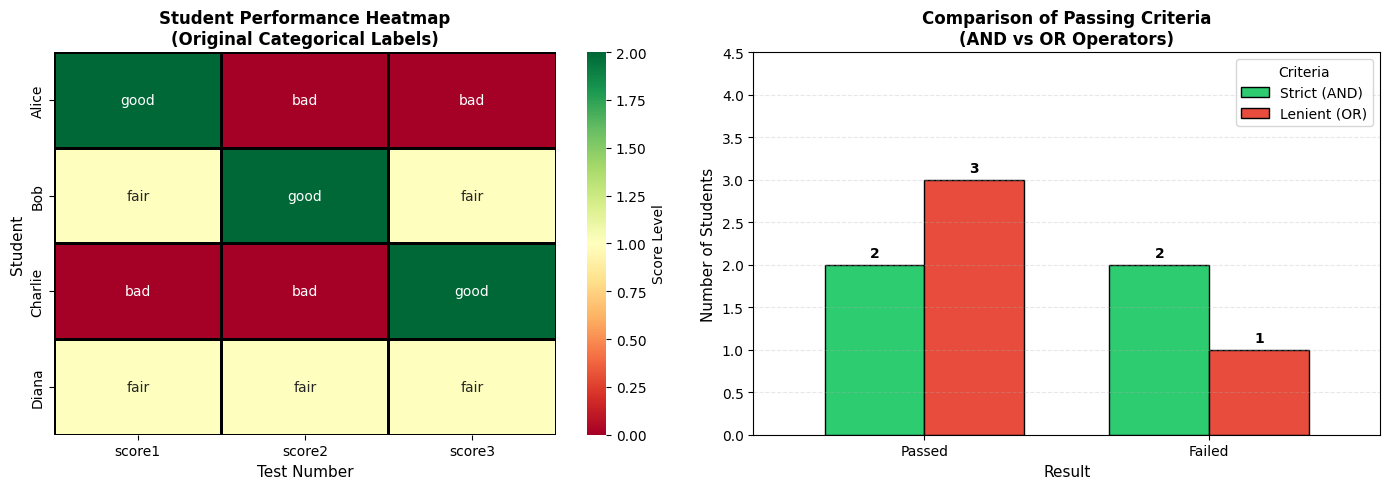


FINAL RESULTS SUMMARY

Complete DataFrame with all columns:
         score1 score2 score3  pass_strict  pass_lenient  failed_strict
Alice         2    bad    bad        False         False           True
Bob           1   good   fair         True          True          False
Charlie       0    bad   good        False          True           True
Diana         1   fair   fair         True          True          False

KEY TAKEAWAYS

1. LABEL ENCODING:
   • Converts text labels to numbers for statistical analysis
   • Use DataFrame.replace() with a dictionary mapping
   • Essential for machine learning and numerical computations

2. BITWISE OPERATORS:
   • & (AND): All conditions must be True - STRICT
   • | (OR): At least one condition must be True - LENIENT
   • ~ (NOT): Inverts True/False values
   • Always use parentheses around each condition!

3. PRACTICAL IMPACT:
   • Strict criteria (AND): 2/4 students passed
   • Lenient criteria (OR): 3/4 students passed
   • Choice of operato

In [47]:

# =============================================================================
# DATA CLEANING EXAMPLE: Label Encoding and Boolean Filtering
# =============================================================================

# Step 1: Create a sample dataset with student scores
# Each student has 3 test scores rated as: 'good', 'fair', or 'bad'
print("STEP 1: Original Data with Categorical Labels")
print("=" * 60)

scores = pd.DataFrame({
    'score1': ['good', 'fair', 'bad', 'fair'],
    'score2': ['bad', 'good', 'bad', 'fair'],
    'score3': ['bad', 'fair', 'good', 'fair']
})

# Add student names for clarity
scores.index = ['Alice', 'Bob', 'Charlie', 'Diana']

print("\nOriginal Scores DataFrame:")
print(scores)

# Save the original values for annotation before any modifications
original_scores_labels = scores.values.copy()

# Visualize the original categorical data as a heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create a copy for visualization (encode temporarily just for the heatmap)
# Force numeric dtype to avoid seaborn/matplotlib TypeError
scores_vis = scores.replace({'good': 2.0, 'fair': 1.0, 'bad': 0.0}).astype(float)

# Subplot 1: Heatmap of original scores
sns.heatmap(scores_vis, annot=original_scores_labels, fmt='', cmap='RdYlGn',
            cbar_kws={'label': 'Score Level'}, ax=axes[0],
            linewidths=1, linecolor='black', vmin=0, vmax=2)
axes[0].set_title('Student Performance Heatmap\n(Original Categorical Labels)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Test Number', fontsize=11)
axes[0].set_ylabel('Student', fontsize=11)

# =============================================================================
# Step 2: LABEL ENCODING - Convert categorical labels to numerical values
# =============================================================================
print("\n" + "=" * 60)
print("STEP 2: Label Encoding (Converting Text to Numbers)")
print("=" * 60)

# Replace categorical values in score1 with numerical values
# Encoding: 'good' → 2, 'fair' → 1, 'bad' → 0
# Note: We specify the column name in the replace() method
scores = scores.replace({"score1": {'good': 2, 'fair': 1, 'bad': 0}})

print("\nAfter encoding score1:")
print(scores)
print(f"\nData type of score1: {scores['score1'].dtype}")  # Now numeric (int64)
print(f"Data type of score2: {scores['score2'].dtype}")  # Still object (string)

# Important Note: We use DataFrame.replace(), NOT str.replace()!
# str.replace() is for string manipulation, not for encoding labels

# =============================================================================
# Step 3: BOOLEAN FILTERING with Bitwise Operators
# =============================================================================
print("\n" + "=" * 60)
print("STEP 3: Boolean Filtering with Bitwise Operators")
print("=" * 60)

# Example 1: AND Operator (&) - Both conditions must be True
# Rule: Student passes if BOTH score2 AND score3 are not 'bad'
print("\nExample 1: AND operator (&) - Strict Passing Criteria")
print("Rule: Pass only if BOTH score2 AND score3 are 'good' or 'fair'")

scores["pass_strict"] = (scores['score2'].isin(['good', 'fair'])) & \
                        (scores['score3'].isin(['good', 'fair']))

print("\nResults with AND (&):")
print(scores[['score2', 'score3', 'pass_strict']])
print(f"\nStudents who passed (strict): {scores['pass_strict'].sum()} out of {len(scores)}")

# Example 2: OR Operator (|) - At least one condition must be True
# Rule: Student passes if EITHER score2 OR score3 is not 'bad'
print("\n" + "-" * 60)
print("Example 2: OR operator (|) - Lenient Passing Criteria")
print("Rule: Pass if AT LEAST ONE of score2 or score3 is 'good' or 'fair'")

scores["pass_lenient"] = (scores['score2'].isin(['good', 'fair'])) | \
                         (scores['score3'].isin(['good', 'fair']))

print("\nResults with OR (|):")
print(scores[['score2', 'score3', 'pass_lenient']])
print(f"\nStudents who passed (lenient): {scores['pass_lenient'].sum()} out of {len(scores)}")

# Example 3: NOT Operator (~) - Negates the condition
print("\n" + "-" * 60)
print("Example 3: NOT operator (~) - Inversion")
print("Find students who did NOT pass the strict criteria")

scores["failed_strict"] = ~scores['pass_strict']

print("\nResults with NOT (~):")
print(scores[['pass_strict', 'failed_strict']])

# =============================================================================
# Step 4: Visualize the complete results
# =============================================================================

# Subplot 2: Bar chart comparing passing criteria
pass_summary = pd.DataFrame({
    'Strict (AND)': [scores['pass_strict'].sum(), (~scores['pass_strict']).sum()],
    'Lenient (OR)': [scores['pass_lenient'].sum(), (~scores['pass_lenient']).sum()]
}, index=['Passed', 'Failed'])

pass_summary.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                  width=0.7, edgecolor='black')
axes[1].set_title('Comparison of Passing Criteria\n(AND vs OR Operators)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Result', fontsize=11)
axes[1].set_ylabel('Number of Students', fontsize=11)
axes[1].set_xticklabels(['Passed', 'Failed'], rotation=0)
axes[1].legend(title='Criteria', fontsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_ylim(0, 4.5)

# Add value labels on bars (compatible with older Matplotlib versions)
for bar in axes[1].patches:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f"{int(height)}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# Final summary
print("\n" + "=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print("\nComplete DataFrame with all columns:")
print(scores)

print("\n" + "=" * 60)
print("KEY TAKEAWAYS")
print("=" * 60)
print("\n1. LABEL ENCODING:")
print("   • Converts text labels to numbers for statistical analysis")
print("   • Use DataFrame.replace() with a dictionary mapping")
print("   • Essential for machine learning and numerical computations")
print("\n2. BITWISE OPERATORS:")
print("   • & (AND): All conditions must be True - STRICT")
print("   • | (OR): At least one condition must be True - LENIENT")
print("   • ~ (NOT): Inverts True/False values")
print("   • Always use parentheses around each condition!")
print("\n3. PRACTICAL IMPACT:")
print(f"   • Strict criteria (AND): {scores['pass_strict'].sum()}/{len(scores)} students passed")
print(f"   • Lenient criteria (OR): {scores['pass_lenient'].sum()}/{len(scores)} students passed")
print("   • Choice of operator significantly affects outcomes!")


## **Bubble Chart - Scatter Plot with Size and Color Dimensions**

A **bubble chart** is an enhanced scatter plot where each data point is represented by a circle (bubble). The position shows two variables (x and y coordinates), the size represents a third variable, and optionally, color can encode a fourth variable. This makes bubble charts excellent for visualizing 3-4 dimensions simultaneously.

### What Does a Bubble Chart Show?

- **Three Variables Simultaneously**: X-position, Y-position, and bubble size all convey information
- **Relationships**: How multiple variables relate to each other
- **Magnitude**: Bubble size emphasizes importance or scale of entities
- **Categories**: When color-coded, shows an additional categorical or continuous dimension
- **Outliers**: Unusually large/small bubbles or extreme positions stand out

### Why Use Bubble Charts?

- **Multi-dimensional**: Shows 3-4 variables in one plot (more than basic scatter plots)
- **Visual Impact**: Bubble size creates strong visual hierarchy - important items stand out
- **Comparisons**: Easy to compare entities across multiple dimensions
- **Storytelling**: Compelling way to present complex data relationships
- **Professional**: Popular in business presentations and data journalism

### When to Use:

- **Business Analysis**:
  - Portfolio analysis (risk vs. return, bubble size = investment amount)
  - Product performance (price vs. margin, bubble size = sales volume)
  - Market segmentation (reach vs. engagement, bubble size = market size)
  - Competitive analysis (quality vs. price, bubble size = market share)

- **Research**:
  - Population studies (GDP vs. life expectancy, bubble size = population)
  - Scientific data (temperature vs. pressure, bubble size = reaction rate)
  - Social sciences (education vs. income, bubble size = sample size)

- **Data Journalism**:
  - Country comparisons across multiple metrics
  - Demographic visualizations
  - Economic indicators

### Dimensions in a Bubble Chart:

1. **X-axis**: First continuous variable (horizontal position)
2. **Y-axis**: Second continuous variable (vertical position)
3. **Bubble Size**: Third continuous variable (area of circle)
4. **Color** (optional): Fourth variable (categorical or continuous)

### Key Parameters:

- `x`, `y`: Position variables
- `s`: Size of bubbles (can be a value or array)
  - Size represents area, so use `s = value * scale_factor` to make differences visible
- `c`: Color (single color, array of colors, or values to map to colormap)
- `alpha`: Transparency (0-1) - important to see overlapping bubbles
- `edgecolors`: Border color around bubbles
- `linewidth`: Thickness of bubble borders
- `cmap`: Colormap if using continuous color scale

### Best Practices:

1. **Scale size appropriately**:
   - Bubble area (not diameter) should be proportional to the value
   - Use: `s = [value * scale_factor for value in size_variable]`
   - Scale factor depends on your data range and figure size

2. **Use transparency**: Set `alpha=0.5-0.7` to see overlapping bubbles

3. **Add bubble borders**: `edgecolors='black'` helps distinguish overlapping bubbles

4. **Limit number of bubbles**: 5-50 bubbles work best. More becomes cluttered

5. **Add labels**: For important bubbles, add text labels with entity names

6. **Include legend**:
   - Size legend: Show what different bubble sizes represent
   - Color legend: If using color for a fourth dimension

7. **Choose colors wisely**: Use categorical colors for groups, sequential colormap for continuous values

### Interpretation Tips:

- **Position**: Main relationships shown by x-y coordinates
- **Size**: Draws attention to most important/largest entities
- **Clusters**: Groups of bubbles suggest similar characteristics
- **Outliers**: Bubbles far from others or unusually large/small
- **Patterns**: Look for correlations - do larger bubbles tend to be in specific regions?

### Common Mistakes to Avoid:

1. ✗ Too many bubbles (>100) - becomes unreadable
2. ✗ No transparency - overlapping bubbles hide each other
3. ✗ Wrong size scaling - using diameter instead of area
4. ✗ No legend - viewers can't interpret size
5. ✗ Cluttered labels - only label key bubbles

### When NOT to Use:

- Simple 2-variable relationship (use regular scatter plot)
- Precise value reading needed (hard to judge bubble size accurately)
- Many data points (>50-100) with significant overlap
- Size variable is not important to the story
- Categorical x or y axis (use grouped bar chart instead)

### Animated Bubble Charts:

Famous example: Hans Rosling's Gapminder visualization showing countries over time, with:
- X: GDP per capita
- Y: Life expectancy
- Size: Population
- Color: Continent
- Animation: Changes over years

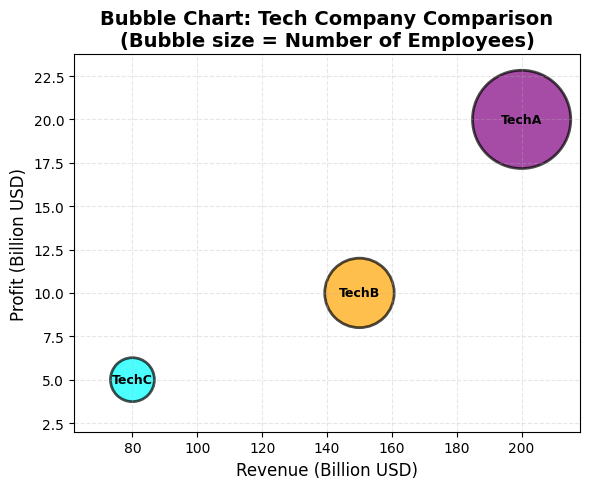

In [48]:
# Sample data: Comparing tech companies across three dimensions
companies = ['TechA', 'TechB', 'TechC']
revenue = [200, 150, 80]      # X-axis: Revenue in billion USD
profit = [20, 10, 5]          # Y-axis: Profit in billion USD
employees = [100, 50, 20]     # Bubble size: Number of employees (thousands)

# Create bubble chart
plt.figure(figsize=(6,5))

# Create scatter plot with sized bubbles
# s: Bubble sizes (multiply by 50 to scale for visibility - area should be proportional)
# c: Colors for each company
# alpha: Transparency to see overlapping bubbles
# edgecolors: Black borders help distinguish bubbles
bubbles = plt.scatter(revenue, profit,
                     s=[e*50 for e in employees],  # Scale employee count to bubble area
                     c=['purple', 'orange', 'cyan'],
                     alpha=0.7,
                     edgecolors='black',
                     linewidth=2)

# Add labels for each company
# Annotate each bubble with the company name
for i, company in enumerate(companies):
    plt.annotate(company, (revenue[i], profit[i]),
                ha='center', va='center', fontweight='bold', fontsize=9)

# Add axis labels and title
plt.xlabel('Revenue (Billion USD)', fontsize=12)
plt.ylabel('Profit (Billion USD)', fontsize=12)
plt.title('Bubble Chart: Tech Company Comparison\n(Bubble size = Number of Employees)',
         fontsize=14, fontweight='bold')

# Add grid for easier reading
plt.grid(True, alpha=0.3, linestyle='--')

# Set axis limits with padding to keep all bubbles inside plot area
# Add 15% padding on all sides to accommodate the largest bubbles
x_range = max(revenue) - min(revenue)
y_range = max(profit) - min(profit)
plt.xlim(min(revenue) - x_range * 0.15, max(revenue) + x_range * 0.15)
plt.ylim(min(profit) - y_range * 0.2, max(profit) + y_range * 0.25)

# Add a custom legend for bubble sizes
# Create properly sized legend entries that won't overflow
# Using smaller sizes for the legend to fit nicely in the legend box
legend_sizes = [20, 50, 100]
legend_elements = [plt.scatter([], [], s=emp*10, c='gray', alpha=0.6,
                               edgecolors='black', linewidth=1.5,
                               label=f'{emp}K employees')
                   for emp in legend_sizes]


plt.tight_layout()
plt.show()

# Interpretation:
# - Position (X, Y): TechA has highest revenue AND profit
# - Size: TechA also has the most employees (largest bubble)
# - TechA dominates on all three dimensions
# - TechC is smallest on all metrics
# - This visualization makes it easy to compare companies across multiple metrics at once!

## **Joint Plot (Bivariate Analysis with Marginal Distributions)**

A **joint plot** is an incredibly powerful and aesthetically pleasing visualization that combines multiple views of bivariate data in a single figure. It displays:

1. **Central Scatter Plot**: Shows the relationship between two continuous variables (like a standard scatter plot)
2. **Marginal Distributions**: Automatically adds distribution plots (histograms or KDE) along the top and right margins, showing the univariate distribution of each variable

### Why Use Joint Plots?

- **Comprehensive Analysis**: See both the relationship between variables AND their individual distributions in one view
- **Pattern Detection**: Identify clusters, outliers, correlations, and distribution shapes simultaneously
- **Professional Appearance**: Creates publication-ready figures with minimal code
- **Flexible Customization**: Supports various plot types (scatter, hex, kde, reg) and statistical annotations

### When to Use:
- Exploring relationships between two continuous variables
- Checking for correlations while understanding individual variable distributions
- Presenting bivariate analysis in research papers or reports
- Identifying patterns that might be missed with scatter plots alone

### Key Parameters:
- `x`, `y`: The two variables to compare
- `data`: Your pandas DataFrame
- `kind`: Type of plot - 'scatter' (default), 'kde', 'hex', or 'reg' (with regression line)
- `hue`: Color by a categorical variable
- `height`: Size of the figure

Example 1: Basic Joint Plot with Histograms


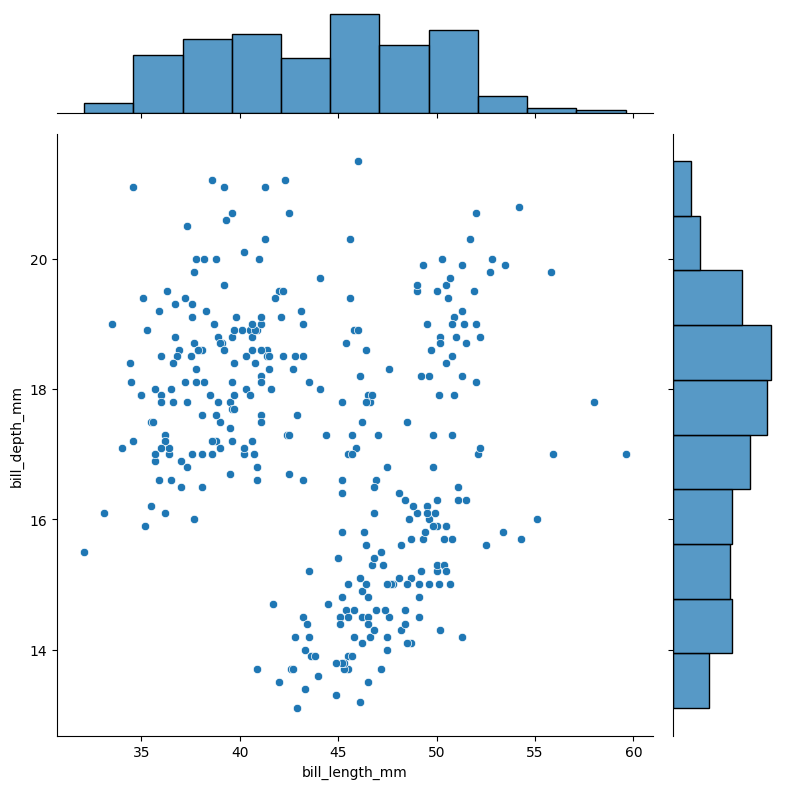


Example 2: Joint Plot with KDE (Smooth Distributions)


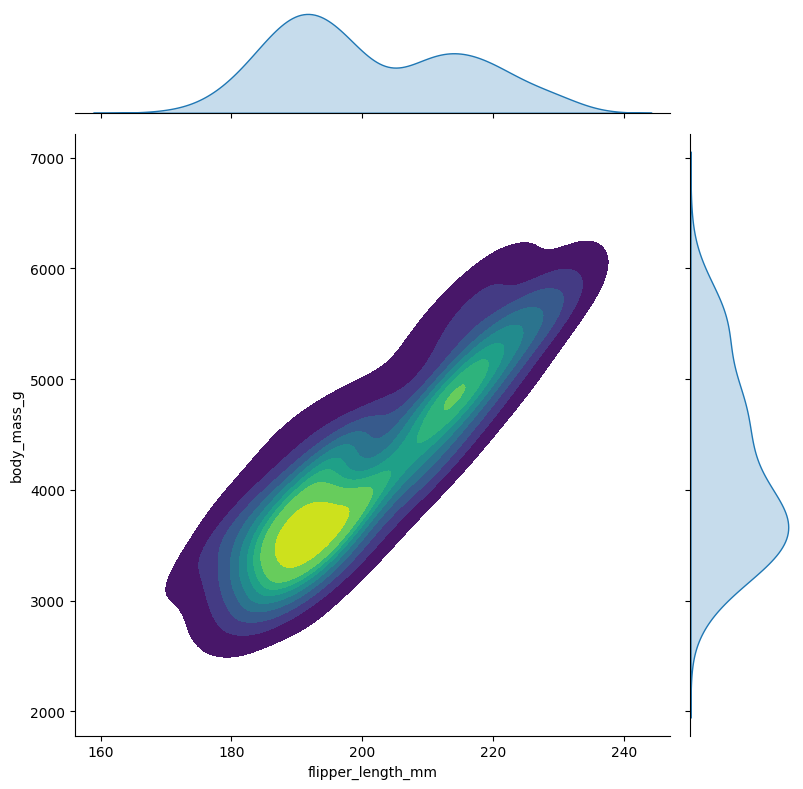


Example 3: Joint Plot with Regression Line (Colored by Species)


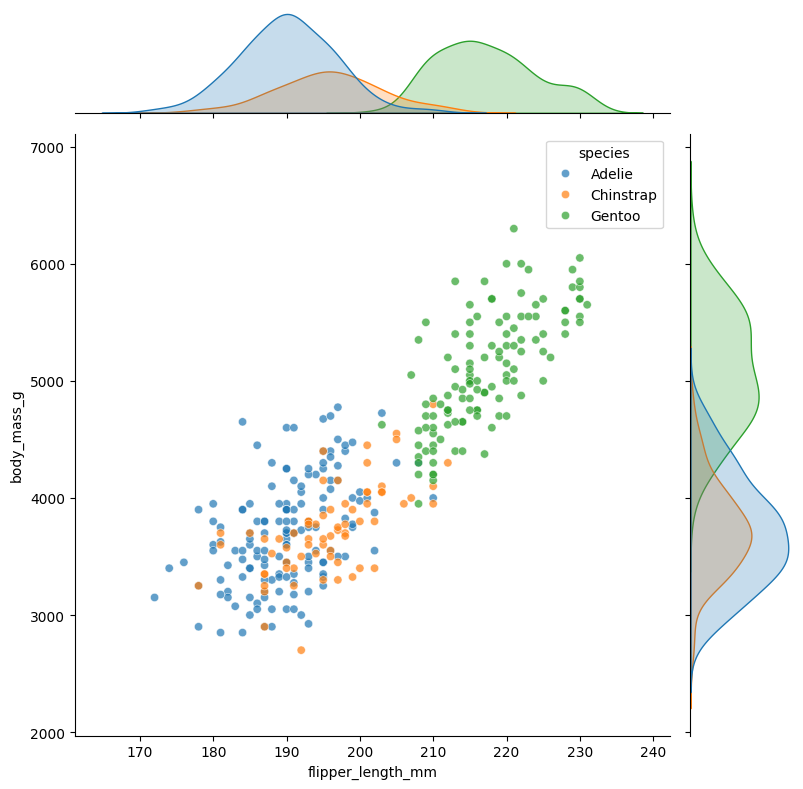


Example 4: Hexbin Joint Plot (Better for Large Datasets)


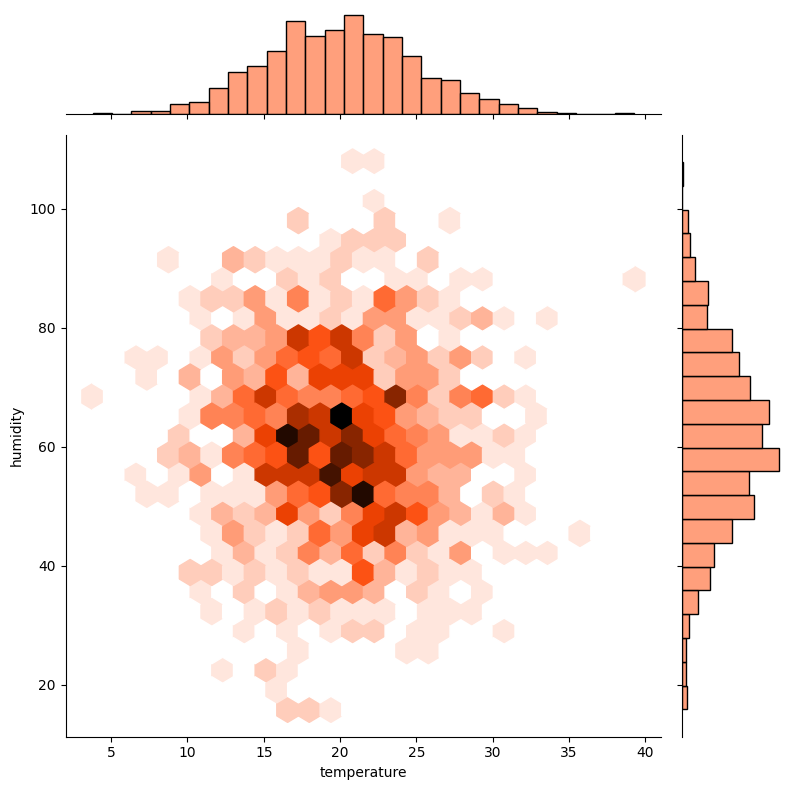

In [49]:
# Load a built-in dataset (penguins - contains measurements of different penguin species)
penguins = sns.load_dataset('penguins').dropna()

# Example 1: Basic joint plot with scatter plot and histograms
print("Example 1: Basic Joint Plot with Histograms")
sns.jointplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', height=8)
plt.show()

# Example 2: Joint plot with KDE (Kernel Density Estimation) for smoother distributions
print("\nExample 2: Joint Plot with KDE (Smooth Distributions)")
sns.jointplot(data=penguins, x='flipper_length_mm', y='body_mass_g',
              kind='kde', height=8, cmap='viridis', fill=True)
plt.show()

# Example 3: Joint plot with regression line and colored by species
print("\nExample 3: Joint Plot with Regression Line (Colored by Species)")
sns.jointplot(data=penguins, x='flipper_length_mm', y='body_mass_g',
              hue='species', kind='scatter', height=8, alpha=0.7)
plt.show()

# Example 4: Hexbin joint plot (great for large datasets to avoid overplotting)
print("\nExample 4: Hexbin Joint Plot (Better for Large Datasets)")
# Create larger synthetic dataset for demonstration
np.random.seed(42)
large_data = {
    'temperature': np.random.normal(20, 5, 1000),
    'humidity': np.random.normal(60, 15, 1000)
}
import pandas as pd
large_df = pd.DataFrame(large_data)

sns.jointplot(data=large_df, x='temperature', y='humidity',
              kind='hex', height=8, color='coral')
plt.show()

## **Ridge Plot (Joy Plot) - Visualizing Distributions Across Categories**

A **ridge plot** (also called a joy plot) is a modern, aesthetically pleasing visualization technique that displays the distribution of a continuous variable across multiple categories. It creates a series of partially overlapping density plots, one for each category, stacked vertically.

### What Makes Ridge Plots Special?

- **Beautiful Aesthetics**: The overlapping curves create an elegant, flowing visual effect
- **Easy Comparison**: Quickly compare distributions across many categories (more than box plots can handle comfortably)
- **Space Efficient**: Shows many distributions without requiring excessive vertical space
- **Trend Visualization**: Can reveal patterns and trends across ordered categories (like time periods)

### Key Components:

1. **Multiple KDE Curves**: Each category gets its own kernel density estimation curve
2. **Vertical Stacking**: Categories are arranged vertically for easy comparison
3. **Partial Overlap**: Curves overlap slightly, creating the characteristic "ridge" effect
4. **Color Gradients**: Often use color gradients to enhance visual appeal and aid interpretation

### When to Use Ridge Plots:

- Comparing distributions across multiple groups (5+ categories work well)
- Showing how distributions change over time or ordered categories
- When you want a more visually appealing alternative to violin plots or multiple histograms
- Presenting data in reports, dashboards, or publications where aesthetics matter

### Perfect For:

- Temperature distributions across months
- Test scores across different classes or schools
- Product ratings across categories
- Sensor readings across different times of day
- Any scenario with multiple overlapping distributions

### Implementation Note:
Ridge plots can be created using seaborn's FacetGrid with KDE plots, or using the specialized `joypy` library for more advanced features.

Example 1: Ridge Plot - Penguin Body Mass by Species


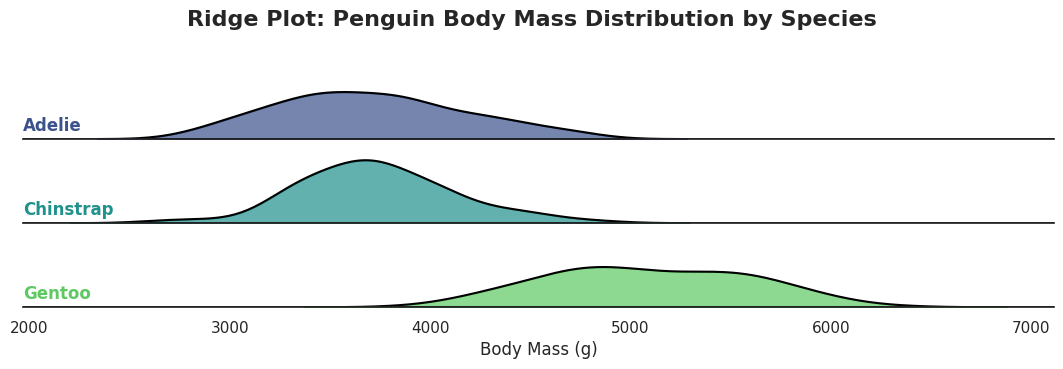


Example 2: Ridge Plot - Temperature Distribution Across Months


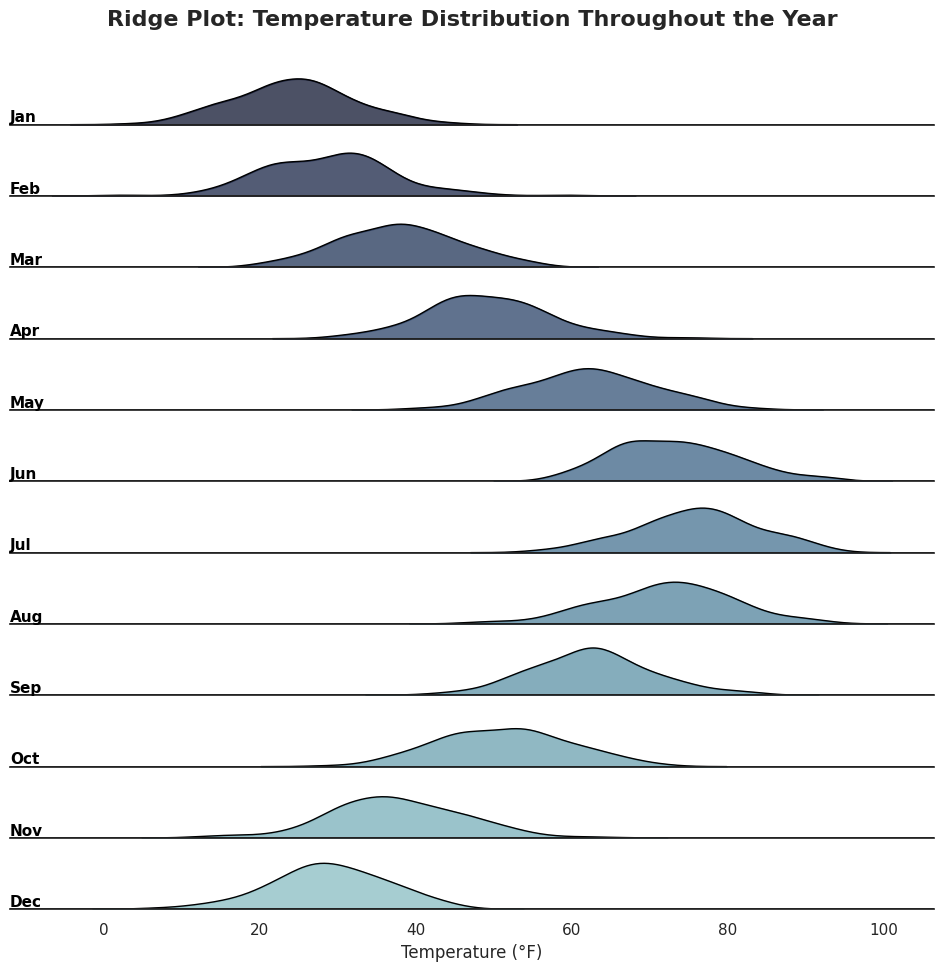


✨ Ridge plots are excellent for comparing distributions across many categories!
💡 Tip: They work best with 5+ categories and continuous data.


In [ ]:
# Example 1: Basic Ridge Plot using Seaborn FacetGrid
print("Example 1: Ridge Plot - Penguin Body Mass by Species")

# Load penguins dataset
penguins = sns.load_dataset('penguins').dropna()

# Create a ridge plot using FacetGrid
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Create the FacetGrid
g = sns.FacetGrid(penguins, row="species", hue="species", aspect=9, height=1.2, palette="viridis")

# Map the densities
g.map(sns.kdeplot, "body_mass_g", fill=True, alpha=0.7)
g.map(sns.kdeplot, "body_mass_g", color="black", linewidth=1.5)

# Add a horizontal line for reference
g.map(plt.axhline, y=0, linewidth=2, color="black")

# Define and use a simple function to label each facet
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, 0.2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes, fontsize=12)

g.map(label, "body_mass_g")

# Set titles and labels
g.fig.suptitle("Ridge Plot: Penguin Body Mass Distribution by Species",
               fontsize=16, fontweight='bold', y=1.02)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set_xlabels("Body Mass (g)", fontsize=12)
g.despine(left=True)

plt.tight_layout()
plt.show()


# Example 2: Ridge Plot with Monthly Temperature Data
print("\nExample 2: Ridge Plot - Temperature Distribution Across Months")

# Create synthetic temperature data for demonstration
np.random.seed(42)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_order = {month: i for i, month in enumerate(months)}

# Generate realistic temperature distributions for each month
temp_data = []
for i, month in enumerate(months):
    # Temperature varies seasonally (simple sine wave pattern)
    mean_temp = 50 + 25 * np.sin((i - 3) * np.pi / 6)
    temps = np.random.normal(mean_temp, 8, 150)
    for temp in temps:
        temp_data.append({'Month': month, 'Temperature': temp, 'Order': i})

temp_df = pd.DataFrame(temp_data)

# Sort by month order
temp_df = temp_df.sort_values('Order')

# Create the ridge plot
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Use a color palette that represents temperature
pal = sns.cubehelix_palette(12, rot=-.25, light=.7, reverse=True)
g = sns.FacetGrid(temp_df, row="Month", hue="Month", aspect=12, height=0.8,
                  palette=pal, row_order=months, hue_order=months)

# Map the densities
g.map(sns.kdeplot, "Temperature", fill=True, alpha=0.8)
g.map(sns.kdeplot, "Temperature", color="black", linewidth=1)
g.map(plt.axhline, y=0, linewidth=2, color="black")

# Label each ridge
def label_month(x, color, label):
    ax = plt.gca()
    ax.text(0, 0.15, label, fontweight="bold", color="black",
            ha="left", va="center", transform=ax.transAxes, fontsize=11)

g.map(label_month, "Temperature")

# Styling
g.fig.suptitle("Ridge Plot: Temperature Distribution Throughout the Year",
               fontsize=16, fontweight='bold', y=1.01)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set_xlabels("Temperature (°F)", fontsize=12)
g.despine(left=True)

plt.tight_layout()
plt.show()

print("\n✨ Ridge plots are excellent for comparing distributions across many categories!")
print("💡 Tip: They work best with 5+ categories and continuous data.")

## Treemap Visualization for Data Analysis

When we analyze data, we often care about **how a total is split across many parts**.  
For example: where does total revenue come from, or which groups dominate a dataset?

A **treemap** is designed exactly for this kind of question.

It represents data using **rectangles packed inside a space**, where:
- Each rectangle is a category (or subcategory)
- The **area of the rectangle represents a numeric value**
- Larger rectangles immediately signal greater contribution to the total

### Why this matters

If you try to understand distribution using a table, you must scan and compare numbers mentally.  
If you use a bar chart, comparisons become easier but can still get cluttered with many categories.

A treemap goes one step further:
> It turns “which is bigger?” into an immediate visual impression.

You don’t read values first — you **see structure first**.

### What treemaps reveal well

Treemaps are especially powerful for spotting:
- Dominant categories (which take most of the space)
- Long-tail behavior (many small contributors)
- Imbalance in distribution (few large vs many small groups)
- Hierarchical structure (category → subcategory patterns)

### Intuition to keep in mind

Think of a treemap as:
> “A visual decomposition of a whole into its parts, where space itself encodes importance.”

This is why treemaps are widely used in:
- Business dashboards (revenue breakdowns)
- System monitoring (resource usage)
- Any analysis where **composition matters more than exact values**

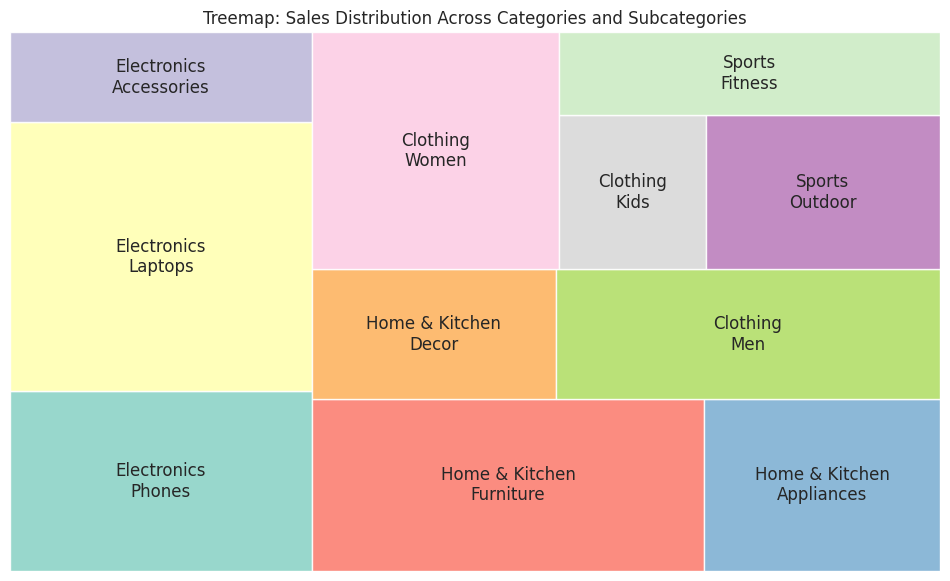

,Sales
Category,
Electronics,360
Home & Kitchen,310
Clothing,290
Sports,150


In [ ]:
!pip install squarify

import squarify
import pandas as pd
import matplotlib.pyplot as plt
# -----------------------------
# Concrete dataset (sales data)
# -----------------------------
data = {
    "Category": [
        "Electronics", "Electronics", "Electronics",
        "Home & Kitchen", "Home & Kitchen", "Home & Kitchen",
        "Clothing", "Clothing", "Clothing",
        "Sports", "Sports"
    ],
    "Subcategory": [
        "Phones", "Laptops", "Accessories",
        "Furniture", "Appliances", "Decor",
        "Men", "Women", "Kids",
        "Outdoor", "Fitness"
    ],
    "Sales": [
        120, 180, 60,
        150, 90, 70,
        110, 130, 50,
        80, 70
    ]
}

df = pd.DataFrame(data)

# -----------------------------
# Prepare labels for treemap
# (Category + Subcategory)
# -----------------------------
df["Label"] = df["Category"] + "\n" + df["Subcategory"]

labels = df["Label"].tolist()
sizes = df["Sales"].tolist()

# -----------------------------
# Plot treemap
# -----------------------------
plt.figure(figsize=(12, 7))

colors = plt.cm.Set3(range(len(labels)))

squarify.plot(
    sizes=sizes,
    label=labels,
    color=colors,
    alpha=0.9
)

plt.title("Treemap: Sales Distribution Across Categories and Subcategories")
plt.axis("off")

plt.show()

# -----------------------------
# Optional analysis insight
# -----------------------------
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

---

## **Summary: Advanced Visualization Tips**

### Choosing Between Joint Plots and Ridge Plots:

**Use Joint Plots when:**
- Analyzing the relationship between TWO continuous variables
- You need to see both correlation AND individual distributions
- Exploring bivariate relationships in depth
- Looking for outliers in two dimensions

**Use Ridge Plots when:**
- Comparing distributions of ONE variable across MULTIPLE categories
- You have 5+ groups to compare
- Aesthetics and visual appeal are important
- Showing changes over time or ordered categories

### General Best Practices:

1. **Color Choice**: Use color palettes that are colorblind-friendly (like 'viridis', 'plasma', 'cividis')
2. **Figure Size**: Adjust `height` parameter to make plots readable - larger for presentations, compact for reports
3. **Data Preprocessing**: Always clean your data (remove NaNs, outliers) before visualization
4. **Context**: Add titles, labels, and annotations to make plots self-explanatory
5. **Combine Techniques**: Don't hesitate to use multiple visualization types to tell your data story

### Additional Resources:
- Seaborn Gallery: https://seaborn.pydata.org/examples/index.html
- Matplotlib Tutorials: https://matplotlib.org/stable/tutorials/index.html
- Python Graph Gallery: https://www.python-graph-gallery.com/

**Remember**: The best visualization is one that clearly communicates your findings to your audience! 📊✨